# Statistical Learning and Data Analytics for Transportation Systems
## Problem Set 2 — Dimensionality Reduction, Logistic Regression, SVM, Decision Trees, Ensembles

**Name:** Mohd Zamin Quadri

This notebook contains the code, outputs and figures behind the report. It follows the
same order as the problem sheet. Problems 1.3 and 3.4 are the parts for which code is
explicitly required, but I have also coded the arithmetic in the other parts so that
every number quoted in the report is reproducible rather than hand-calculated.

All paths are relative to the folder containing this notebook. Figures are written to
`figures/` and result tables to `results/`.

In [1]:
import warnings
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path("figures")
RES_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
})
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


def save(fig, name):
    """Write a figure to figures/ and report where it went."""
    path = FIG_DIR / name
    fig.savefig(path)
    print(f"saved -> {path}")


def find_data(filename):
    """Locate a data file without hard-coding an absolute path."""
    for candidate in (Path("data") / filename, Path(filename), Path("..") / filename):
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found near {Path.cwd()}")

---
# Problem 1 — Binomial logistic regression and principal components (35 points)

The dependent variable is the observed travel mode, coded 0 for walking and 1 for car.
Both models are binomial logits, so for respondent $i$

$$\Pr(\text{car}_i = 1 \mid \mathbf{x}_i) = \frac{1}{1 + e^{-\eta_i}},
\qquad \eta_i = \beta_0 + \sum_{j=1}^{K}\beta_j x_{ij}.$$

The two estimated models are given in the problem sheet as printed output, so I enter the
reported coefficients, standard errors and BIC values directly rather than re-estimating
them.

## 1.1 Comparing the two models

Model 2 is Model 1 with `Indiv_trvl_frequency` removed, so the models are *nested* and
both were fitted on the same $n = 244{,}493$ observations. That allows two complementary
comparisons.

**Penalised likelihood.** $\text{BIC} = -2\ln\hat{L} + k\ln n$, where $k$ counts all
estimated parameters including the intercept. Because $n$ and the data are identical,
the BIC values are directly comparable and I can also invert the formula to recover the
maximised log-likelihood of each model.

**Likelihood-ratio test.** For nested models,
$\Lambda = 2(\ln\hat{L}_1 - \ln\hat{L}_2) \sim \chi^2_1$ under the null hypothesis
$H_0: \beta_{\text{Indiv\_trvl\_frequency}} = 0$.

In [2]:
N_OBS = 244493

model1 = pd.DataFrame({
    "estimate": [-2.126e0, 9.786e-4, 1.716e-2, 1.611e-2, 1.012e0, -2.463e-2],
    "std_error": [2.700e-2, 1.037e-05, 3.858e-04, 4.748e-04, 8.924e-03, 3.285e-03],
    "z_value": [-78.723, 94.334, 44.485, 33.937, 113.359, -7.497],
    "p_value": [np.nan, np.nan, np.nan, np.nan, np.nan, 6.54e-14],
}, index=["(Intercept)", "TrvlTime", "Age", "Indiv_trvl_frequency", "HHVeh", "HHsize"])

model2 = pd.DataFrame({
    "estimate": [-2.038e0, 9.465e-4, 1.711e-2, 1.188e0, -9.367e-3],
    "std_error": [2.689e-2, 1.026e-05, 3.876e-04, 7.544e-03, 3.244e-03],
    "z_value": [-75.778, 92.282, 44.149, 157.549, -2.888],
    "p_value": [np.nan, np.nan, np.nan, np.nan, 0.00388],
}, index=["(Intercept)", "TrvlTime", "Age", "HHVeh", "HHsize"])

BIC = {"Model 1": 95815.66, "Model 2": 97047.6}
K = {"Model 1": len(model1), "Model 2": len(model2)}

print("Model 1 (5 regressors):"); print(model1)
print("\nModel 2 (4 regressors):"); print(model2)

Model 1 (5 regressors):
                      estimate  std_error  z_value  p_value
(Intercept)            -2.1260     0.0270 -78.7230      NaN
TrvlTime                0.0010     0.0000  94.3340      NaN
Age                     0.0172     0.0004  44.4850      NaN
Indiv_trvl_frequency    0.0161     0.0005  33.9370      NaN
HHVeh                   1.0120     0.0089 113.3590      NaN
HHsize                 -0.0246     0.0033  -7.4970   0.0000

Model 2 (4 regressors):
             estimate  std_error  z_value  p_value
(Intercept)   -2.0380     0.0269 -75.7780      NaN
TrvlTime       0.0009     0.0000  92.2820      NaN
Age            0.0171     0.0004  44.1490      NaN
HHVeh          1.1880     0.0075 157.5490      NaN
HHsize        -0.0094     0.0032  -2.8880   0.0039


In [3]:
# Recover the maximised log-likelihood from BIC = -2 lnL + k ln(n), then form AIC.
ln_n = np.log(N_OBS)
fit = pd.DataFrame({
    "k (parameters)": pd.Series(K),
    "BIC (reported)": pd.Series(BIC),
})
fit["log-likelihood"] = -(fit["BIC (reported)"] - fit["k (parameters)"] * ln_n) / 2
fit["AIC"] = -2 * fit["log-likelihood"] + 2 * fit["k (parameters)"]

lr_stat = 2 * (fit.loc["Model 1", "log-likelihood"] - fit.loc["Model 2", "log-likelihood"])
lr_p = stats.chi2.sf(lr_stat, df=1)

print(f"ln(n) = {ln_n:.6f}   with n = {N_OBS:,}")
print(fit.round(3))
print(f"\nDelta BIC (Model 2 - Model 1) = {BIC['Model 2'] - BIC['Model 1']:.2f}")
print(f"Delta AIC (Model 2 - Model 1) = {fit.loc['Model 2','AIC'] - fit.loc['Model 1','AIC']:.2f}")
print(f"\nLikelihood-ratio test of H0: beta_Indiv_trvl_frequency = 0")
print(f"  Lambda = {lr_stat:.2f} on 1 d.f.,  p = {lr_p:.3e}")
fit.round(3).to_csv(RES_DIR / "p1_1_model_fit_comparison.csv")

ln(n) = 12.406942   with n = 244,493
         k (parameters)  BIC (reported)  log-likelihood        AIC
Model 1               6      95815.6600     -47870.6090 95753.2180
Model 2               5      97047.6000     -48492.7830 96995.5650

Delta BIC (Model 2 - Model 1) = 1231.94
Delta AIC (Model 2 - Model 1) = 1242.35

Likelihood-ratio test of H0: beta_Indiv_trvl_frequency = 0
  Lambda = 1244.35 on 1 d.f.,  p = 1.405e-272


In [4]:
# How much does dropping Indiv_trvl_frequency move the surviving coefficients?
shared = ["(Intercept)", "TrvlTime", "Age", "HHVeh", "HHsize"]
shift = pd.DataFrame({
    "Model 1": model1.loc[shared, "estimate"],
    "Model 2": model2.loc[shared, "estimate"],
    "|z| Model 1": model1.loc[shared, "z_value"].abs(),
    "|z| Model 2": model2.loc[shared, "z_value"].abs(),
})
shift["change (%)"] = 100 * (shift["Model 2"] - shift["Model 1"]) / shift["Model 1"].abs()
print(shift.round(4))
shift.round(4).to_csv(RES_DIR / "p1_1_coefficient_shift.csv")

print("\nOdds ratios exp(beta) for Model 1:")
odds = np.exp(model1.loc[model1.index != "(Intercept)", "estimate"])
print(odds.round(5))
print(f"\nTrvlTime odds ratio per extra 10 minutes (600 s): "
      f"{np.exp(model1.loc['TrvlTime','estimate'] * 600):.4f}")

             Model 1  Model 2  |z| Model 1  |z| Model 2  change (%)
(Intercept)  -2.1260  -2.0380      78.7230      75.7780      4.1392
TrvlTime      0.0010   0.0009      94.3340      92.2820     -3.2802
Age           0.0172   0.0171      44.4850      44.1490     -0.2914
HHVeh         1.0120   1.1880     113.3590     157.5490     17.3913
HHsize       -0.0246  -0.0094       7.4970       2.8880     61.9691

Odds ratios exp(beta) for Model 1:
TrvlTime               1.0010
Age                    1.0173
Indiv_trvl_frequency   1.0162
HHVeh                  2.7511
HHsize                 0.9757
Name: estimate, dtype: float64

TrvlTime odds ratio per extra 10 minutes (600 s): 1.7989


**Reading the output.** Every parameter in both models is significant at any conventional
level, so significance alone cannot separate them. The discriminating evidence is the
penalised likelihood: Model 1 has the lower BIC by 1231.9 points, and on the usual
Kass–Raftery reading anything above 10 is decisive. The likelihood-ratio test agrees
overwhelmingly — the extra regressor buys 622 log-likelihood points for one degree of
freedom.

The coefficient shift table shows how sensitive the remaining parameters are to the
exclusion. `HHVeh` moves from 1.012 to 1.188 and `HHsize` shrinks by about 62%, with its
$|z|$ falling from 7.50 to 2.89. These changes are consistent with omitted-variable bias —
`Indiv_trvl_frequency` and `HHVeh` are positively correlated in the sample examined in 1.3,
so the vehicle coefficient can absorb part of the dropped variable's effect — but in a
logistic model they are also consistent with **non-collapsibility**, whereby omitting any
covariate that predicts the outcome changes the remaining coefficients even without
confounding. The printed output alone cannot separate the two mechanisms. What it does
establish is that the reduced specification is materially sensitive to the exclusion, which
is a second reason to prefer Model 1.

Two cautions on this reading. The correlation of 0.61 comes from the 5000-row sample of
1.3, whereas the models are estimated on 244,493 observations, so it is indicative rather
than a direct measurement on the estimation sample. And `HHsize` remains statistically
significant in Model 2 ($p = 0.0039$); it is its estimated magnitude and precision that
fall sharply, not its significance.

## 1.2 Predicted probability of choosing the car

Using Model 1, for each respondent I form the linear predictor and pass it through the
logistic link:

$$\eta = \hat\beta_0 + \hat\beta_1\,\text{TrvlTime} + \hat\beta_2\,\text{Age}
        + \hat\beta_3\,\text{Indiv\_trvl\_frequency} + \hat\beta_4\,\text{HHVeh}
        + \hat\beta_5\,\text{HHsize},
\qquad \hat P(\text{car}) = \frac{e^{\eta}}{1+e^{\eta}}.$$

The odds of choosing the car are simply $e^{\eta}$.

In [5]:
respondents = pd.DataFrame(
    {"TrvlTime": [3650, 200], "Age": [60, 26], "Indiv_trvl_frequency": [24, 7],
     "HHVeh": [2, 0], "HHsize": [2, 1]},
    index=["A", "B"])
print("Inputs (TrvlTime in seconds):"); print(respondents)

beta = model1["estimate"]
regressors = list(respondents.columns)

# Term-by-term contributions to the linear predictor, so the arithmetic is visible.
contrib = respondents.mul(beta[regressors], axis=1)
contrib.insert(0, "(Intercept)", beta["(Intercept)"])
contrib["eta"] = contrib.sum(axis=1)
contrib["odds = exp(eta)"] = np.exp(contrib["eta"])
contrib["P(car)"] = 1 / (1 + np.exp(-contrib["eta"]))
print("\nContribution of each term to the linear predictor:")
print(contrib.round(5))
contrib.round(6).to_csv(RES_DIR / "p1_2_predicted_probabilities.csv")

for name in contrib.index:
    print(f"\nRespondent {name}:  eta = {contrib.loc[name,'eta']:.4f}, "
          f"odds = {contrib.loc[name,'odds = exp(eta)']:.3f}, "
          f"P(car) = {contrib.loc[name,'P(car)']:.4f}  "
          f"(P(walk) = {1 - contrib.loc[name,'P(car)']:.4f})")

Inputs (TrvlTime in seconds):
   TrvlTime  Age  Indiv_trvl_frequency  HHVeh  HHsize
A      3650   60                    24      2       2
B       200   26                     7      0       1

Contribution of each term to the linear predictor:
   (Intercept)  TrvlTime    Age  Indiv_trvl_frequency  HHVeh  HHsize     eta  odds = exp(eta)  P(car)
A      -2.1260    3.5719 1.0296                0.3866 2.0240 -0.0493  4.8369         126.0741  0.9921
B      -2.1260    0.1957 0.4462                0.1128 0.0000 -0.0246 -1.3960           0.2476  0.1984

Respondent A:  eta = 4.8369, odds = 126.074, P(car) = 0.9921  (P(walk) = 0.0079)

Respondent B:  eta = -1.3960, odds = 0.248, P(car) = 0.1985  (P(walk) = 0.8015)


saved -> figures\p1_2_probability_curves.png


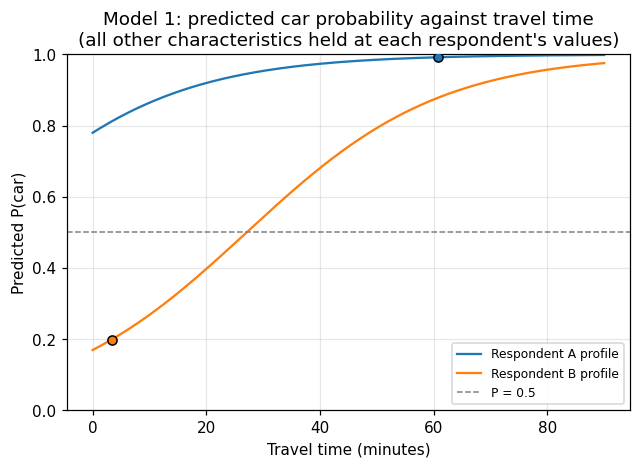

In [6]:
# Sensitivity: how the two respondents' probabilities respond to travel time,
# holding their other characteristics fixed. This shows the non-linearity of the
# marginal effect, which a linear probability model would miss.
t_grid = np.linspace(0, 5400, 400)
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for name, colour in zip(["A", "B"], ["tab:blue", "tab:orange"]):
    row = respondents.loc[name].copy()
    eta = (beta["(Intercept)"]
           + beta["TrvlTime"] * t_grid
           + beta["Age"] * row["Age"]
           + beta["Indiv_trvl_frequency"] * row["Indiv_trvl_frequency"]
           + beta["HHVeh"] * row["HHVeh"]
           + beta["HHsize"] * row["HHsize"])
    ax.plot(t_grid / 60, 1 / (1 + np.exp(-eta)), color=colour,
            label=f"Respondent {name} profile")
    ax.scatter([row["TrvlTime"] / 60], [contrib.loc[name, "P(car)"]],
               color=colour, zorder=5, edgecolor="k")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="P = 0.5")
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Predicted P(car)")
ax.set_title("Model 1: predicted car probability against travel time\n"
             "(all other characteristics held at each respondent's values)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
save(fig, "p1_2_probability_curves.png")
plt.show()

**Interpretation.** Respondent A is predicted to travel by car with probability 0.992,
respondent B with probability 0.198. The gap is large but consistent with the fitted
parameters and with what the two profiles represent.

Respondent A faces a 3650-second (about 61-minute) trip, is 60 years old, travels often,
and lives in a two-person household with two cars. Every one of those characteristics
pushes the linear predictor upward; travel time alone contributes $+3.57$ and vehicle
ownership $+2.02$. With $\eta = 4.84$ the odds of driving are about 126 to 1, so the model
treats A as an almost certain car user.

Respondent B faces a 200-second (roughly 3-minute) trip, is 26, travels less often, and —
decisively — lives in a one-person household with **no** car at all. Because `HHVeh`
carries by far the largest coefficient (an odds ratio of 2.75 per vehicle), owning no
vehicle removes the single strongest driver of car use, and $\eta = -1.40$ leaves only a
20% chance of driving. That the model still assigns a fifth of the probability to the car
for a car-free household on a three-minute trip is worth flagging: it reflects the fact
that 78.8% of the survey sample travelled by car, so the model's baseline propensity is
high, and access to a car outside the household (lifts, car-sharing, taxis) is not
represented among the regressors.

The curves also make the non-linearity explicit. B's probability is on the steep part of
the logistic curve, so an extra ten minutes of travel time moves it substantially, whereas
A is already saturated near 1 and barely responds. This is exactly why the coefficients
themselves are not marginal effects — the same $\hat\beta$ produces very different changes
in probability depending on where a respondent sits on the curve.

## 1.3 Principal components analysis of the independent variables

Principal components analysis rotates the predictors into uncorrelated linear combinations
ordered by the variance they capture. Writing $\mathbf{Z}$ for the standardised data
matrix, the components are the eigenvectors $\mathbf{v}_j$ of the correlation matrix
$\mathbf{R} = \tfrac{1}{n-1}\mathbf{Z}^{\top}\mathbf{Z}$, and the eigenvalue $\lambda_j$ is
the variance carried by component $j$. Since $\operatorname{tr}(\mathbf{R}) = K$, the
eigenvalues sum to the number of variables.

Two decisions matter here:

1. **`travel_mode` is excluded.** It is the dependent variable of the logit models, and the
   question asks for a PCA of the *independent* variables.
2. **The variables are standardised.** Travel time is measured in seconds and runs into the
   tens of thousands, while household size runs from 1 to 13. Without standardisation the
   first component would simply be travel time, reflecting its units rather than any
   structure in the data. I demonstrate this below.

In [7]:
csv_path = find_data("mode_choice_pcasample.csv")
survey = pd.read_csv(csv_path)
print(f"loaded {csv_path}  ->  shape {survey.shape}")
print("\nColumns and types:"); print(survey.dtypes)
print("\nMissing values per column:"); print(survey.isna().sum().to_string())
print(f"\nFully duplicated rows: {survey.duplicated().sum()}")
print("\nDependent variable travel_mode (0 = walk, 1 = car):")
print(survey["travel_mode"].value_counts().rename("count"))
print(f"share travelling by car = {survey['travel_mode'].mean():.4f}")
survey.head()

loaded data\mode_choice_pcasample.csv  ->  shape (5000, 6)

Columns and types:
travel_mode               int64
TrvlTime_number         float64
Age                       int64
indiv_trvl_frequency      int64
HHVeh                     int64
HHsize                    int64
dtype: object

Missing values per column:
travel_mode             0
TrvlTime_number         0
Age                     0
indiv_trvl_frequency    0
HHVeh                   0
HHsize                  0

Fully duplicated rows: 46

Dependent variable travel_mode (0 = walk, 1 = car):
travel_mode
1    3942
0    1058
Name: count, dtype: int64
share travelling by car = 0.7884


,travel_mode,TrvlTime_number,Age,indiv_trvl_frequency,HHVeh,HHsize
0,0,335.0000,19,8,1,2
1,1,511.0000,67,96,4,6
2,0,900.0000,29,36,2,3
3,1,120.0000,47,28,2,3
4,1,660.0000,40,10,1,4


In [8]:
X = survey.drop(columns="travel_mode")
print("Independent variables entering the PCA:", list(X.columns))
print("\nDescriptive statistics:")
print(X.describe().T[["count", "mean", "std", "min", "50%", "max"]])
print("\nSkewness:"); print(X.skew().round(3))
X.describe().T.round(4).to_csv(RES_DIR / "p1_3_descriptives.csv")

Independent variables entering the PCA: ['TrvlTime_number', 'Age', 'indiv_trvl_frequency', 'HHVeh', 'HHsize']

Descriptive statistics:
                         count      mean       std     min      50%        max
TrvlTime_number      5000.0000 1057.7097 1476.0318  6.0000 660.0000 37764.0000
Age                  5000.0000   44.8820   14.8604 16.0000  44.0000    94.0000
indiv_trvl_frequency 5000.0000   28.6070   20.7353  3.0000  24.0000   192.0000
HHVeh                5000.0000    1.7966    0.9181  0.0000   2.0000     7.0000
HHsize               5000.0000    3.6764    1.7044  1.0000   4.0000    13.0000

Skewness:
TrvlTime_number        11.0070
Age                     0.2460
indiv_trvl_frequency    2.3740
HHVeh                   0.6550
HHsize                  0.7940
dtype: float64


saved -> figures\p1_3_correlation_matrix.png


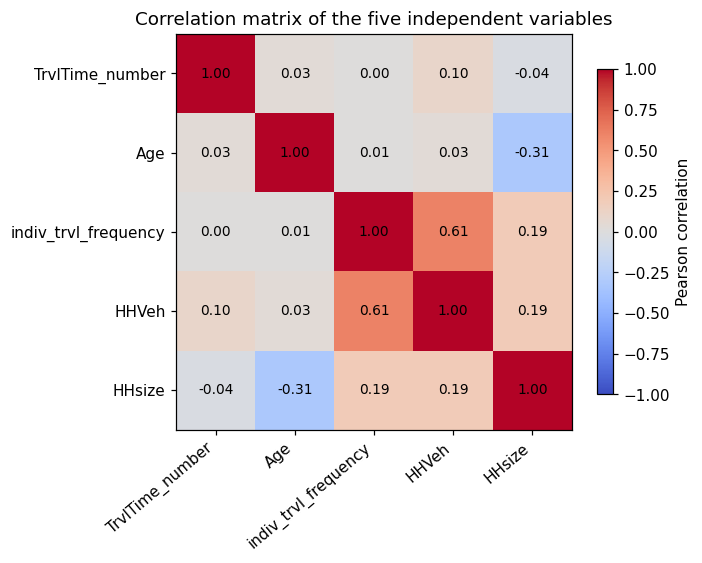

                      TrvlTime_number     Age  indiv_trvl_frequency  HHVeh  HHsize
TrvlTime_number                1.0000  0.0322                0.0021 0.0954 -0.0373
Age                            0.0322  1.0000                0.0074 0.0339 -0.3133
indiv_trvl_frequency           0.0021  0.0074                1.0000 0.6087  0.1882
HHVeh                          0.0954  0.0339                0.6087 1.0000  0.1925
HHsize                        -0.0373 -0.3133                0.1882 0.1925  1.0000


In [9]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlation matrix of the five independent variables")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
save(fig, "p1_3_correlation_matrix.png")
plt.show()
print(corr.round(4))
corr.round(4).to_csv(RES_DIR / "p1_3_correlation_matrix.csv")

In [10]:
from sklearn.decomposition import PCA

# Standardise with the SAMPLE standard deviation (ddof=1) so that the sample
# covariance of Z is exactly the correlation matrix and the eigenvalues sum to
# K exactly. sklearn's StandardScaler divides by the population standard
# deviation (ddof=0), which would inflate the trace by n/(n-1) = 1.0002.
Z = ((X - X.mean()) / X.std(ddof=1)).values

pca = PCA()
scores = pca.fit_transform(Z)

eigenvalues = pca.explained_variance_
evr = pca.explained_variance_ratio_
labels = [f"PC{i+1}" for i in range(len(eigenvalues))]

variance_table = pd.DataFrame({
    "eigenvalue": eigenvalues,
    "proportion of variance": evr,
    "cumulative proportion": np.cumsum(evr),
}, index=labels)
print(variance_table.round(4))
print(f"\nsum of eigenvalues = {eigenvalues.sum():.4f}  (equals the number of variables, K = {X.shape[1]})")
print(f"components with eigenvalue > 1 (Kaiser): "
      f"{[l for l, e in zip(labels, eigenvalues) if e > 1]}")
cum = np.cumsum(evr)
print(f"cumulative variance at 2 components = {cum[1]:.4f}")
print(f"cumulative variance at 3 components = {cum[2]:.4f}  "
      f"(just short of the 0.80 target)")
print(f"components needed to strictly exceed 80% = {int(np.searchsorted(cum, 0.80) + 1)}")
variance_table.round(6).to_csv(RES_DIR / "p1_3_variance_explained.csv")

     eigenvalue  proportion of variance  cumulative proportion
PC1      1.7248                  0.3450                 0.3450
PC2      1.2668                  0.2534                 0.5983
PC3      0.9867                  0.1973                 0.7957
PC4      0.6386                  0.1277                 0.9234
PC5      0.3831                  0.0766                 1.0000

sum of eigenvalues = 5.0000  (equals the number of variables, K = 5)
components with eigenvalue > 1 (Kaiser): ['PC1', 'PC2']
cumulative variance at 2 components = 0.5983
cumulative variance at 3 components = 0.7957  (just short of the 0.80 target)
components needed to strictly exceed 80% = 4


saved -> figures\p1_3_scree_and_variance.png


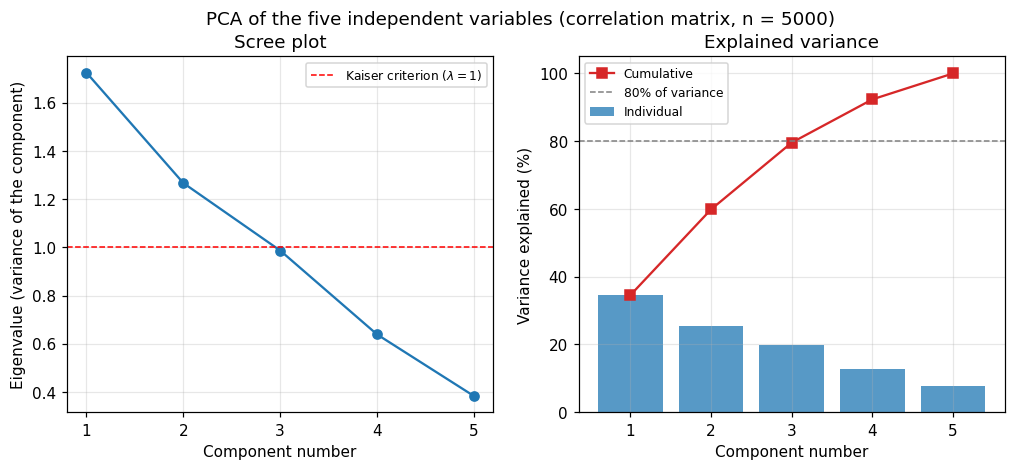

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(range(1, len(eigenvalues) + 1), eigenvalues, "o-", color="tab:blue")
ax.axhline(1.0, color="red", ls="--", lw=1, label="Kaiser criterion ($\\lambda = 1$)")
ax.set_xticks(range(1, len(eigenvalues) + 1))
ax.set_xlabel("Component number")
ax.set_ylabel("Eigenvalue (variance of the component)")
ax.set_title("Scree plot")
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(range(1, len(evr) + 1), evr * 100, color="tab:blue", alpha=0.75,
       label="Individual")
ax.plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, "s-", color="tab:red",
        label="Cumulative")
ax.axhline(80, color="grey", ls="--", lw=1, label="80% of variance")
ax.set_xticks(range(1, len(evr) + 1))
ax.set_xlabel("Component number")
ax.set_ylabel("Variance explained (%)")
ax.set_title("Explained variance")
ax.legend(fontsize=8)

fig.suptitle("PCA of the five independent variables (correlation matrix, n = 5000)")
save(fig, "p1_3_scree_and_variance.png")
plt.show()

Loadings (correlation of each variable with each component):
                         PC1     PC2     PC3     PC4     PC5
TrvlTime_number       0.0800  0.2880  0.9510  0.0380 -0.0670
Age                  -0.1700  0.8120 -0.2210  0.5130 -0.0290
indiv_trvl_frequency  0.8430  0.2320 -0.1620 -0.1670 -0.4270
HHVeh                 0.8460  0.2840 -0.0220 -0.0870  0.4410
HHsize                0.5130 -0.6250  0.0820  0.5820 -0.0260

Eigenvectors (weights used to build each component):
                         PC1     PC2     PC3     PC4     PC5
TrvlTime_number       0.0610  0.2560  0.9570  0.0480 -0.1080
Age                  -0.1290  0.7210 -0.2220  0.6420 -0.0470
indiv_trvl_frequency  0.6420  0.2060 -0.1630 -0.2090 -0.6900
HHVeh                 0.6450  0.2520 -0.0230 -0.1090  0.7130
HHsize                0.3910 -0.5550  0.0830  0.7280 -0.0420

Communality retained by PC1-PC3 (sum of squared loadings):
TrvlTime_number        0.9940
Age                    0.7360
indiv_trvl_frequency   0.7900
HHV

saved -> figures\p1_3_loadings.png


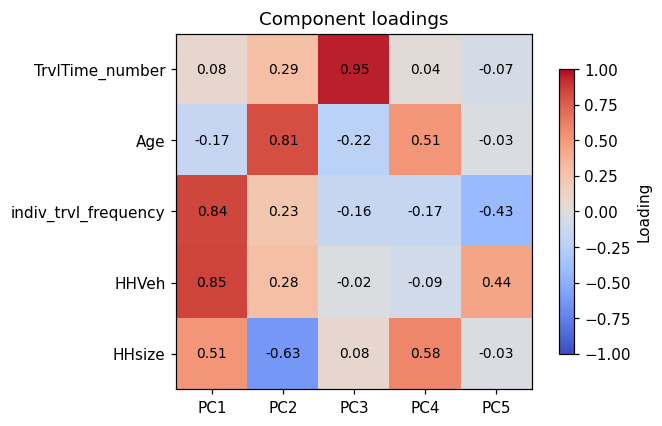

In [12]:
# Loadings: correlation between each original variable and each component,
# computed as eigenvector * sqrt(eigenvalue).
loadings = pd.DataFrame(pca.components_.T * np.sqrt(eigenvalues),
                        index=X.columns, columns=labels)
eigenvectors = pd.DataFrame(pca.components_.T, index=X.columns, columns=labels)

print("Loadings (correlation of each variable with each component):")
print(loadings.round(3))
print("\nEigenvectors (weights used to build each component):")
print(eigenvectors.round(3))
print("\nCommunality retained by PC1-PC3 (sum of squared loadings):")
print((loadings[["PC1", "PC2", "PC3"]] ** 2).sum(axis=1).round(3))

loadings.round(4).to_csv(RES_DIR / "p1_3_loadings.csv")
eigenvectors.round(4).to_csv(RES_DIR / "p1_3_eigenvectors.csv")

fig, ax = plt.subplots(figsize=(6.4, 4.2))
im = ax.imshow(loadings.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(X.columns))); ax.set_yticklabels(X.columns)
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        ax.text(j, i, f"{loadings.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Component loadings")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Loading")
save(fig, "p1_3_loadings.png")
plt.show()

saved -> figures\p1_3_biplot.png


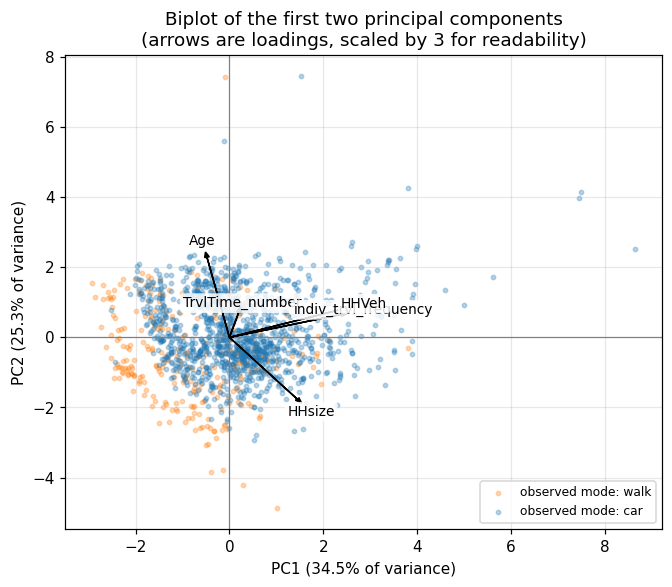

In [13]:
# Biplot of the first two components. Scores are thinned for readability and
# coloured by the observed travel mode purely as a visual check - travel_mode
# played no part in fitting the PCA.
rng_plot = np.random.default_rng(RANDOM_STATE)
idx = rng_plot.choice(len(scores), size=1500, replace=False)

fig, ax = plt.subplots(figsize=(7.0, 5.6))
for mode, colour, name in [(0, "tab:orange", "walk"), (1, "tab:blue", "car")]:
    sel = idx[survey["travel_mode"].values[idx] == mode]
    ax.scatter(scores[sel, 0], scores[sel, 1], s=8, alpha=0.30, color=colour,
               label=f"observed mode: {name}")

arrow_scale = 3.0
for var in X.columns:
    vx, vy = loadings.loc[var, "PC1"], loadings.loc[var, "PC2"]
    ax.arrow(0, 0, vx * arrow_scale, vy * arrow_scale, color="black",
             head_width=0.10, length_includes_head=True, zorder=6)
    ax.text(vx * arrow_scale * 1.13, vy * arrow_scale * 1.13, var,
            fontsize=9, ha="center", va="center", zorder=7,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% of variance)")
ax.set_title("Biplot of the first two principal components\n"
             "(arrows are loadings, scaled by 3 for readability)")
ax.legend(fontsize=8, loc="lower right")
save(fig, "p1_3_biplot.png")
plt.show()

In [14]:
# Check 1: what happens without standardisation. Reported only to justify the
# choice of the correlation matrix - this is not the answer to the question.
pca_raw = PCA().fit(X.values)
print("Explained variance ratio on UNSTANDARDISED data:")
print(pd.Series(pca_raw.explained_variance_ratio_, index=labels).round(6))
print("-> PC1 is essentially TrvlTime_number alone, an artefact of measuring it in seconds.\n")

# Check 2: TrvlTime_number is strongly right-skewed (skew = 11.0). Does a log
# transform change the conclusion about how many components to keep?
X_log = X.copy()
X_log["TrvlTime_number"] = np.log(X_log["TrvlTime_number"])
pca_log = PCA().fit(((X_log - X_log.mean()) / X_log.std(ddof=1)).values)
sens = pd.DataFrame({
    "eigenvalue (raw)": eigenvalues,
    "cumulative (raw)": np.cumsum(evr),
    "eigenvalue (log TrvlTime)": pca_log.explained_variance_,
    "cumulative (log TrvlTime)": np.cumsum(pca_log.explained_variance_ratio_),
}, index=labels)
print("Sensitivity of the eigenvalue spectrum to log-transforming travel time:")
print(sens.round(4))
sens.round(4).to_csv(RES_DIR / "p1_3_sensitivity_log_traveltime.csv")

Explained variance ratio on UNSTANDARDISED data:
PC1   0.9997
PC2   0.0002
PC3   0.0001
PC4   0.0000
PC5   0.0000
dtype: float64
-> PC1 is essentially TrvlTime_number alone, an artefact of measuring it in seconds.

Sensitivity of the eigenvalue spectrum to log-transforming travel time:
     eigenvalue (raw)  cumulative (raw)  eigenvalue (log TrvlTime)  cumulative (log TrvlTime)
PC1            1.7248            0.3450                     1.7250                     0.3450
PC2            1.2668            0.5983                     1.2812                     0.6013
PC3            0.9867            0.7957                     0.9815                     0.7976
PC4            0.6386            0.9234                     0.6343                     0.9244
PC5            0.3831            1.0000                     0.3780                     1.0000


**How many components to keep.** The three usual rules do not fully agree, so it is worth
stating each one:

- *Kaiser criterion* ($\lambda_j > 1$): keep **two** components. PC3, however, has
  $\lambda_3 = 0.987$, which misses the threshold by about 1%, so this is a borderline call
  rather than a clean cut.
- *Cumulative variance*: PC1–PC2 retain 59.8%, and adding PC3 brings the total to 79.6%.
  That is marginally short of the customary 80% target — strictly, **four** components
  would be required to exceed it, which would leave almost no reduction at all.
- *Scree plot*: there is no sharp elbow. The eigenvalues decline gently from 1.73 to 0.38,
  which is itself the most informative result here.

I nominate **three components**, retaining 79.6% of the total variance. Neither rule
selects three outright, so the choice needs an argument. PC3 sits essentially on the Kaiser
boundary ($\lambda_3 = 0.987$, short by about 1%) and takes the cumulative share to within
half a percentage point of the 80% target, so on both criteria it is a borderline
inclusion rather than a clear exclusion. What settles it is substantive: PC3 is almost
entirely travel time (loading 0.95), and travel time is the predictor most directly exposed
to transport policy — service frequency, network design and congestion management all act
on it, whereas age, household size and vehicle ownership are socio-demographic
characteristics an authority does not control. Dropping the most policy-relevant dimension
in the data to satisfy thresholds it misses by a hundredth would be the wrong trade. Two components would be defensible if the goal were strictly variance-driven
compression; I state the alternative because the rules genuinely disagree.

The communalities show what three components actually preserve of each original variable:
travel time is almost fully retained (0.994), `HHVeh` 0.798, `indiv_trvl_frequency` 0.790,
`Age` 0.736 and `HHsize` only 0.661. So a third of the variation in household size is lost
even under the more generous choice.

**What the components mean.** PC1 (34.5%) loads on `indiv_trvl_frequency` (0.84),
`HHVeh` (0.85) and `HHsize` (0.51), and is best read as *household mobility resources and
activity* — larger, better-motorised households whose members travel more often. PC2
(25.3%) contrasts `Age` (0.81) against `HHsize` (−0.63), a *life-stage* dimension
separating older, smaller households from younger, larger ones. PC3 (19.7%) is
effectively travel time on its own, which is consistent with travel time being almost
uncorrelated with every socio-demographic variable in the sample (all $|r| \le 0.10$).

**The honest headline is that PCA compresses this dataset rather little.** Five variables
reduce to three for a 20% loss of variance — a modest saving. The reason is visible in
the correlation matrix: only one pair is appreciably correlated
($r = 0.61$ between `indiv_trvl_frequency` and `HHVeh`, the same collinearity that is
consistent with the coefficient sensitivity seen in 1.1), while the remaining pairs sit below
0.32 in absolute value. PCA can only exploit redundancy that exists, and here there is
little of it. That is a useful negative result: unlike the freeway data of Problem Set 1,
where flow and occupancy were near-duplicates with VIFs above 90, these survey predictors
are largely carrying independent information, and a modeller would be better served by
keeping the original variables — which are directly interpretable — than by substituting
components.

**Caveats.** Travel time is severely right-skewed (skewness 11.0, maximum 37,764 s), and
PCA is defined on second moments, so it is sensitive to such tails. The sensitivity check
shows that log-transforming travel time leaves the eigenvalue spectrum essentially
unchanged (cumulative variance for three components moves from 79.6% to 79.7%), so the
conclusion is robust on this point. Two further limitations should be kept in mind:
`HHVeh` and `HHsize` are discrete counts rather than continuous variables, so the
correlation matrix is only an approximation of their association; and PCA is unsupervised,
so a component that captures little variance may still matter for predicting mode choice.
Components should not be selected for a classification model on the basis of eigenvalues
alone.

---
# Problem 2 — Support vector machines and a decision-tree split (30 points)

The dataset is the eight points of Table 2 in the problem sheet.

In [15]:
p2 = pd.DataFrame({
    "x1": [1.5, 1.5, 3.5, 3.5, 0.5, 0.5, 2.5, 2.5],
    "x2": [1.0, 3.0, 1.0, 3.0, 0.0, 2.0, 0.0, 2.0],
    "y":  [1, 1, 1, 1, -1, -1, -1, -1],
})
X2 = p2[["x1", "x2"]].to_numpy(float)
y2 = p2["y"].to_numpy(int)
print(p2.to_string(index=False))
print(f"\nclass counts: {dict(zip(*np.unique(y2, return_counts=True)))}")

    x1     x2  y
1.5000 1.0000  1
1.5000 3.0000  1
3.5000 1.0000  1
3.5000 3.0000  1
0.5000 0.0000 -1
0.5000 2.0000 -1
2.5000 0.0000 -1
2.5000 2.0000 -1

class counts: {np.int64(-1): np.int64(4), np.int64(1): np.int64(4)}


## 2.1 Plotting the data

saved -> figures\p2_1_data.png


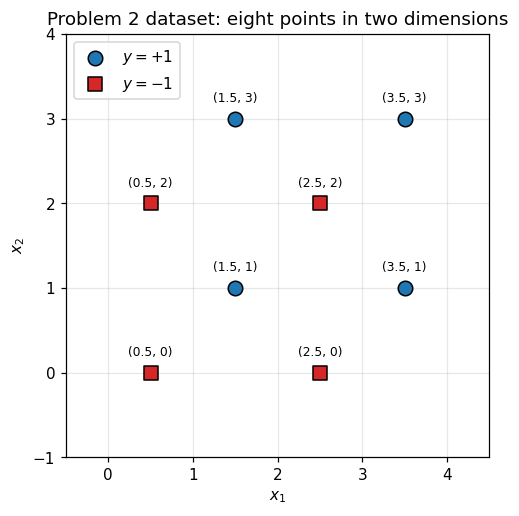

In [16]:
def scatter_classes(ax, XX, yy, s=90):
    ax.scatter(XX[yy == 1, 0], XX[yy == 1, 1], marker="o", s=s, c="tab:blue",
               edgecolor="k", label="$y = +1$", zorder=5)
    ax.scatter(XX[yy == -1, 0], XX[yy == -1, 1], marker="s", s=s, c="tab:red",
               edgecolor="k", label="$y = -1$", zorder=5)

fig, ax = plt.subplots(figsize=(5.8, 5.0))
scatter_classes(ax, X2, y2)
for (a, b), lab in zip(X2, y2):
    ax.annotate(f"({a:g}, {b:g})", (a, b), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=8)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Problem 2 dataset: eight points in two dimensions")
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-1.0, 4.0)
ax.set_aspect("equal"); ax.legend()
save(fig, "p2_1_data.png")
plt.show()

The two classes interleave along both axes. Moving along $x_1$ the labels alternate
$-1, +1, -1, +1$ at $x_1 = 0.5, 1.5, 2.5, 3.5$, and along $x_2$ they alternate
$-1, +1, -1, +1$ at $x_2 = 0, 1, 2, 3$. No straight line can separate them, which is what
parts 2.3 to 2.5 address.

## 2.2 Information gain rate of the rule $x_1 \ge 1$

For a node $S$ the entropy is $H(S) = -\sum_k p_k \log_2 p_k$. Splitting $S$ into children
$S_v$ gives

$$\text{IG} = H(S) - \sum_v \frac{|S_v|}{|S|} H(S_v),
\qquad
\text{SI} = -\sum_v \frac{|S_v|}{|S|}\log_2\frac{|S_v|}{|S|},
\qquad
\text{gain ratio} = \frac{\text{IG}}{\text{SI}}.$$

The *information gain rate* (gain ratio) adjusts the raw gain by the intrinsic information
of the split. It mainly counters information gain's preference for attributes with many
branches, although it may itself favour highly unbalanced splits when the split information
is very small.
I report both the raw gain and the rate.

In [17]:
def entropy(counts):
    c = np.asarray([v for v in counts if v > 0], dtype=float)
    if c.size == 0:
        return 0.0
    p = c / c.sum()
    return float(-(p * np.log2(p)).sum())


branch = np.where(X2[:, 0] >= 1, "x1 >= 1", "x1 < 1")
table = pd.crosstab(branch, y2)
table.columns = [f"y = {c}" for c in table.columns]
print("Partition induced by the rule:"); print(table)

n_total = len(y2)
parent = [(y2 == 1).sum(), (y2 == -1).sum()]
H_parent = entropy(parent)

children, weighted_H = {}, 0.0
for name in ["x1 >= 1", "x1 < 1"]:
    mask = branch == name
    counts = [(y2[mask] == 1).sum(), (y2[mask] == -1).sum()]
    w = mask.sum() / n_total
    children[name] = (counts, mask.sum(), w, entropy(counts))
    weighted_H += w * entropy(counts)

info_gain = H_parent - weighted_H
split_info = entropy([children[n][1] for n in children])
gain_ratio = info_gain / split_info

print(f"\nParent node: {parent[0]} positive, {parent[1]} negative  ->  H = {H_parent:.6f} bits")
for name, (counts, size, w, h) in children.items():
    print(f"  {name:9s}: n = {size}, weight = {w:.3f}, "
          f"({counts[0]} positive, {counts[1]} negative)  ->  H = {h:.6f}")
print(f"\nWeighted child entropy = {weighted_H:.6f}")
print(f"Information gain       = {info_gain:.6f} bits")
print(f"Split information      = {split_info:.6f} bits")
print(f"Information gain rate  = {gain_ratio:.6f}")

# Cross-check with the training accuracy of the stated rule.
rule_pred = np.where(X2[:, 0] >= 1, 1, -1)
print(f"\nTraining accuracy of the rule = {(rule_pred == y2).mean():.3f} "
      f"({(rule_pred == y2).sum()}/{n_total} correct)")

Partition induced by the rule:
         y = -1  y = 1
row_0                 
x1 < 1        2      0
x1 >= 1       2      4

Parent node: 4 positive, 4 negative  ->  H = 1.000000 bits
  x1 >= 1  : n = 6, weight = 0.750, (4 positive, 2 negative)  ->  H = 0.918296
  x1 < 1   : n = 2, weight = 0.250, (0 positive, 2 negative)  ->  H = -0.000000

Weighted child entropy = 0.688722
Information gain       = 0.311278 bits
Split information      = 0.811278 bits
Information gain rate  = 0.383689

Training accuracy of the rule = 0.750 (6/8 correct)


**Result.** $H(\text{parent}) = 1$ bit exactly, because the parent is a balanced 4/4 node.
The rule sends six points to the branch $x_1 \ge 1$ (four positive, two negative,
$H = 0.918$) and two points to $x_1 < 1$ (both negative, $H = 0$, a pure leaf). The
weighted child entropy is $0.688722$, giving

$$\text{IG} = 1 - 0.688722 = 0.311278 \text{ bits},\qquad
\text{SI} = 0.811278,\qquad
\text{gain ratio} = 0.383689.$$

The rule is informative but far from sufficient. It isolates the two points at $x_1 = 0.5$
perfectly, yet the larger branch remains impure because the points at $x_1 = 2.5$ are
negative and sit on the same side of the threshold as the positives. The rule classifies
6 of 8 points correctly.

Note that the gain ratio (0.384) exceeds the raw gain (0.311). For a **binary** split the
split information is $\mathrm{SI} = H(|S_L|/|S|)$, which attains its maximum of exactly one
bit at an even 50/50 partition and *decreases* as the partition becomes more uneven. So
$\mathrm{SI} \le 1$ always holds for a two-way split, and dividing by it can only raise the
score; here the 6/2 partition gives $\mathrm{SI} = 0.811$. Values above one bit require
more than two branches. The gain ratio exists mainly to counteract information gain's
preference for attributes with many possible values — it is what would penalise a rule
that split the eight points into eight singleton branches. A known side effect is that,
because a very uneven split has small SI, the gain ratio can itself favour highly
unbalanced splits, which is usually managed by ranking only those splits whose raw gain is
at least average.

## 2.3 Soft-margin linear SVM

The soft-margin (C-SVM) primal problem is

$$\min_{\mathbf{w},b,\xi}\ \tfrac12\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i
\quad\text{subject to}\quad
y_i(\mathbf{w}^{\top}\mathbf{x}_i + b) \ge 1 - \xi_i,\ \ \xi_i \ge 0 .$$

Before fitting, it is worth establishing *why* no linear model can succeed here. By the
separating hyperplane theorem, two finite point sets are linearly separable if and only if
their convex hulls are disjoint. Here the positive points form the rectangle
$[1.5, 3.5] \times [1, 3]$ and the negative points the rectangle
$[0.5, 2.5] \times [0, 2]$. These overlap on $[1.5, 2.5] \times [1, 2]$, so the hulls are
not disjoint and the data are provably not linearly separable. Any point in the
intersection, such as $(2.0, 1.5)$, can be written as a convex combination of the positive
points *and* as a convex combination of the negative points, which is verified numerically
below. Consequently some slack variables must be positive at the optimum whatever $C$ is
chosen, and the model cannot reach zero training error. I fit with $C = 1$ and also report
a sweep over $C$ to show the conclusion does not depend on that choice.

In [18]:
# Verify non-separability via the convex-hull criterion rather than by inspection.
pos, neg = X2[y2 == 1], X2[y2 == -1]
lo = np.maximum(pos.min(axis=0), neg.min(axis=0))
hi = np.minimum(pos.max(axis=0), neg.max(axis=0))
print(f"positive-class convex hull : [{pos[:,0].min()}, {pos[:,0].max()}] x "
      f"[{pos[:,1].min()}, {pos[:,1].max()}]")
print(f"negative-class convex hull : [{neg[:,0].min()}, {neg[:,0].max()}] x "
      f"[{neg[:,1].min()}, {neg[:,1].max()}]")
print(f"intersection               : [{lo[0]}, {hi[0]}] x [{lo[1]}, {hi[1]}]"
      f"   -> non-empty: {bool((lo < hi).all())}")

# Exhibit one point of the intersection as a convex combination of each class.
witness = np.array([2.0, 1.5])
w_pos = np.array([0.5625, 0.1875, 0.1875, 0.0625])
w_neg = np.array([0.0625, 0.1875, 0.1875, 0.5625])
print(f"\nwitness point {witness}:")
print(f"  from positives: weights {w_pos} (sum {w_pos.sum():.1f}) -> {w_pos @ pos}")
print(f"  from negatives: weights {w_neg} (sum {w_neg.sum():.1f}) -> {w_neg @ neg}")
print(f"  reproduced by both classes: "
      f"{np.allclose(w_pos @ pos, witness) and np.allclose(w_neg @ neg, witness)}")
print("\nThe convex hulls therefore intersect, so by the separating hyperplane theorem")
print("no linear boundary can classify all eight points correctly.")

positive-class convex hull : [1.5, 3.5] x [1.0, 3.0]
negative-class convex hull : [0.5, 2.5] x [0.0, 2.0]
intersection               : [1.5, 2.5] x [1.0, 2.0]   -> non-empty: True

witness point [2.  1.5]:
  from positives: weights [0.5625 0.1875 0.1875 0.0625] (sum 1.0) -> [2.  1.5]
  from negatives: weights [0.0625 0.1875 0.1875 0.5625] (sum 1.0) -> [2.  1.5]
  reproduced by both classes: True

The convex hulls therefore intersect, so by the separating hyperplane theorem
no linear boundary can classify all eight points correctly.


In [19]:
from sklearn.svm import SVC

sweep = []
for C in [0.1, 0.5, 1.0, 10.0, 100.0]:
    m = SVC(kernel="linear", C=C).fit(X2, y2)
    w = m.coef_.ravel()
    sweep.append({"C": C, "w1": w[0], "w2": w[1], "b": m.intercept_[0],
                  "margin 2/||w||": 2 / np.linalg.norm(w),
                  "n support vectors": len(m.support_),
                  "training accuracy": m.score(X2, y2)})
sweep = pd.DataFrame(sweep).set_index("C")
print(sweep.round(4))
sweep.round(4).to_csv(RES_DIR / "p2_3_svm_C_sweep.csv")

svm_lin = SVC(kernel="linear", C=1.0).fit(X2, y2)
w, b = svm_lin.coef_.ravel(), svm_lin.intercept_[0]
pred_lin = svm_lin.predict(X2)
print(f"\nChosen model (C = 1): w = [{w[0]:.4f}, {w[1]:.4f}], b = {b:.4f}")
print(f"decision boundary:  {w[0]:.3f} x1 + {w[1]:.3f} x2 + ({b:.3f}) = 0")
print(f"margin width 2/||w|| = {2 / np.linalg.norm(w):.4f}")
print(f"training accuracy    = {svm_lin.score(X2, y2):.3f}")
print(f"support vector indices: {svm_lin.support_.tolist()}")
print("\nPer-point outcome:")
detail = p2.copy()
detail["decision f(x)"] = svm_lin.decision_function(X2)
detail["predicted"] = pred_lin
detail["correct"] = pred_lin == y2
detail["support vector"] = [i in svm_lin.support_ for i in range(len(p2))]
print(detail.round(3).to_string(index=False))
detail.round(4).to_csv(RES_DIR / "p2_3_svm_points.csv", index=False)

             w1     w2       b  margin 2/||w||  n support vectors  training accuracy
C                                                                                   
0.1000   0.3333 0.3333 -1.1667          4.2426                  8             0.7500
0.5000   0.5000 0.5000 -1.7500          2.8284                  6             0.7500
1.0000   1.0000 1.0000 -3.5000          1.4142                  6             0.7500
10.0000  1.0000 1.0000 -3.5000          1.4142                  6             0.7500
100.0000 1.0000 1.0000 -3.5000          1.4142                  6             0.7500

Chosen model (C = 1): w = [1.0000, 1.0000], b = -3.5000
decision boundary:  1.000 x1 + 1.000 x2 + (-3.500) = 0
margin width 2/||w|| = 1.4142
training accuracy    = 0.750
support vector indices: [5, 6, 7, 0, 1, 2]

Per-point outcome:
    x1     x2  y  decision f(x)  predicted  correct  support vector
1.5000 1.0000  1        -1.0000         -1    False            True
1.5000 3.0000  1         1.0000    

saved -> figures\p2_3_linear_svm.png


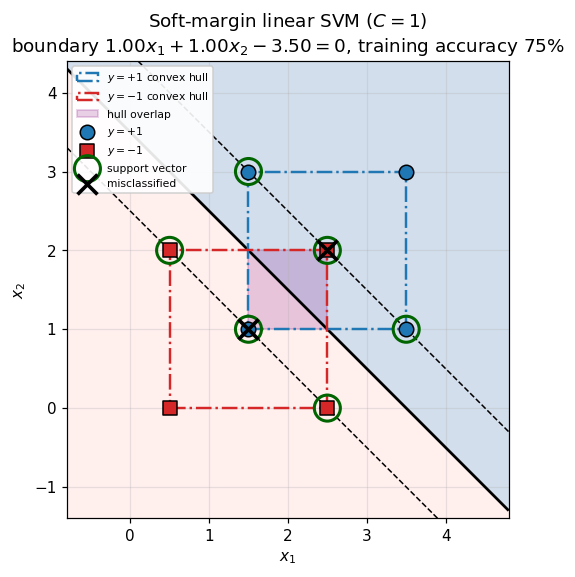

In [20]:
xx, yy = np.meshgrid(np.linspace(-0.8, 4.8, 400), np.linspace(-1.4, 4.4, 400))
zz = svm_lin.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.contourf(xx, yy, zz, levels=[-1e9, 0, 1e9], colors=["mistyrose", "lightsteelblue"],
            alpha=0.55, zorder=0)
ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors="k",
           linestyles=["--", "-", "--"], linewidths=[1, 1.8, 1], zorder=2)

# Draw the two convex hulls to show why no linear boundary can work.
from matplotlib.patches import Rectangle
for pts, colour, name in [(pos, "tab:blue", "$y=+1$ convex hull"),
                          (neg, "tab:red", "$y=-1$ convex hull")]:
    ax.add_patch(Rectangle((pts[:, 0].min(), pts[:, 1].min()),
                           np.ptp(pts[:, 0]), np.ptp(pts[:, 1]),
                           fill=False, edgecolor=colour, lw=1.6, ls="-.",
                           zorder=3, label=name))
ax.add_patch(Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1],
                       facecolor="purple", alpha=0.18, edgecolor="purple",
                       lw=1.2, zorder=1, label="hull overlap"))
scatter_classes(ax, X2, y2)
ax.scatter(X2[svm_lin.support_, 0], X2[svm_lin.support_, 1], s=290,
           facecolors="none", edgecolors="darkgreen", linewidths=2.0,
           label="support vector", zorder=6)
wrong = pred_lin != y2
ax.scatter(X2[wrong, 0], X2[wrong, 1], marker="x", s=170, c="black",
           linewidths=2.4, label="misclassified", zorder=7)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title(f"Soft-margin linear SVM ($C = 1$)\n"
             f"boundary ${w[0]:.2f}x_1 + {w[1]:.2f}x_2 {b:+.2f} = 0$, "
             f"training accuracy {svm_lin.score(X2, y2):.0%}")
ax.set_xlim(-0.8, 4.8); ax.set_ylim(-1.4, 4.4)
ax.set_aspect("equal"); ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
save(fig, "p2_3_linear_svm.png")
plt.show()

**Result.** With $C = 1$ the fitted boundary is $x_1 + x_2 - 3.5 = 0$, with margin width
$2/\|\mathbf{w}\| = 1.414$ and six of the eight points acting as support vectors. Training
accuracy is 75%: the points $(1.5, 1.0)$ and $(2.5, 2.0)$ fall on the wrong side of the
boundary. This is the best a linear model can do, and the convex-hull check above explains
why — the two classes overlap in the region $[1.5, 2.5] \times [1, 2]$, so any straight
line must cut through points of both classes.

The $C$ sweep confirms the failure is structural rather than a tuning artefact. Every value
from $C = 0.1$ to $C = 100$ yields the same 75% training accuracy; increasing $C$ only
shrinks the margin (from 4.24 at $C = 0.1$ to 1.41 from $C = 1$ upward) as the penalty on
slack grows, without ever fixing the misclassified points. This is precisely the situation
the kernel trick and explicit feature maps are designed for, and is the motivation for
parts 2.4 to 2.6.

## 2.4 An explicit mapping that makes the data linearly separable

The class labels are *periodic* in both coordinates with period 2. Positive points have
$x_1 \in \{1.5, 3.5\}$ and $x_2 \in \{1, 3\}$; negative points have $x_1 \in \{0.5, 2.5\}$
and $x_2 \in \{0, 2\}$. Taking each coordinate modulo 2 therefore removes the periodicity
and collapses each class onto a single point. Define $\varphi : \mathbb{R}^2 \to \mathbb{R}^2$
by

$$\varphi(x_1, x_2) = \big(x_1 \ \mathrm{mod}\  2,\ x_2 \ \mathrm{mod}\  2\big),$$

using the mathematical modulus, whose result always lies in $[0, 2)$ (so
$-0.5 \ \mathrm{mod}\  2 = 1.5$). Under this map every positive point goes to $(1.5, 1)$ and every
negative point to $(0.5, 0)$, and the two images are trivially separable, for example by
$z_1 + z_2 = 1.5$.

A smooth alternative giving the same partition is
$\tilde\varphi(x_1, x_2) = (\sin \pi x_1,\ \cos \pi x_2)$, which sends the positives to
$(-1, -1)$ and the negatives to $(+1, +1)$. I verify below that both maps produce identical
predictions, so the answer does not depend on the choice.

In [21]:
def phi_mod(A):
    """Modulo-2 feature map; np.mod returns a non-negative result."""
    A = np.atleast_2d(np.asarray(A, dtype=float))
    return np.column_stack([np.mod(A[:, 0], 2.0), np.mod(A[:, 1], 2.0)])


def phi_trig(A):
    """Smooth equivalent with the same period-2 structure."""
    A = np.atleast_2d(np.asarray(A, dtype=float))
    return np.column_stack([np.sin(np.pi * A[:, 0]), np.cos(np.pi * A[:, 1])])


Zmod = phi_mod(X2)
mapped = p2.copy()
mapped["z1 = x1 mod 2"] = Zmod[:, 0]
mapped["z2 = x2 mod 2"] = Zmod[:, 1]
print("Original points and their images under phi:")
print(mapped.to_string(index=False))
print("\nDistinct images per class:")
for lab in (1, -1):
    print(f"  y = {lab:+d}  ->  {np.unique(Zmod[y2 == lab], axis=0).tolist()}")
print("\nSmooth alternative phi_trig:")
print(np.unique(np.round(phi_trig(X2), 12), axis=0).tolist())

# A hard-margin linear SVM now separates the mapped data perfectly.
svm_mapped = SVC(kernel="linear", C=1e6).fit(Zmod, y2)
wm, bm = svm_mapped.coef_.ravel(), svm_mapped.intercept_[0]
print(f"\nLinear SVM in the mapped space: w = [{wm[0]:.3f}, {wm[1]:.3f}], b = {bm:.3f}")
print(f"separating rule:  {wm[0]:.2f} z1 + {wm[1]:.2f} z2 + ({bm:.2f}) = 0")
print(f"training accuracy in the mapped space = {svm_mapped.score(Zmod, y2):.3f}")

Original points and their images under phi:
    x1     x2  y  z1 = x1 mod 2  z2 = x2 mod 2
1.5000 1.0000  1         1.5000         1.0000
1.5000 3.0000  1         1.5000         1.0000
3.5000 1.0000  1         1.5000         1.0000
3.5000 3.0000  1         1.5000         1.0000
0.5000 0.0000 -1         0.5000         0.0000
0.5000 2.0000 -1         0.5000         0.0000
2.5000 0.0000 -1         0.5000         0.0000
2.5000 2.0000 -1         0.5000         0.0000

Distinct images per class:
  y = +1  ->  [[1.5, 1.0]]
  y = -1  ->  [[0.5, 0.0]]

Smooth alternative phi_trig:
[[-1.0, -1.0], [1.0, 1.0]]

Linear SVM in the mapped space: w = [1.000, 1.000], b = -1.500
separating rule:  1.00 z1 + 1.00 z2 + (-1.50) = 0
training accuracy in the mapped space = 1.000


saved -> figures\p2_4_feature_map.png


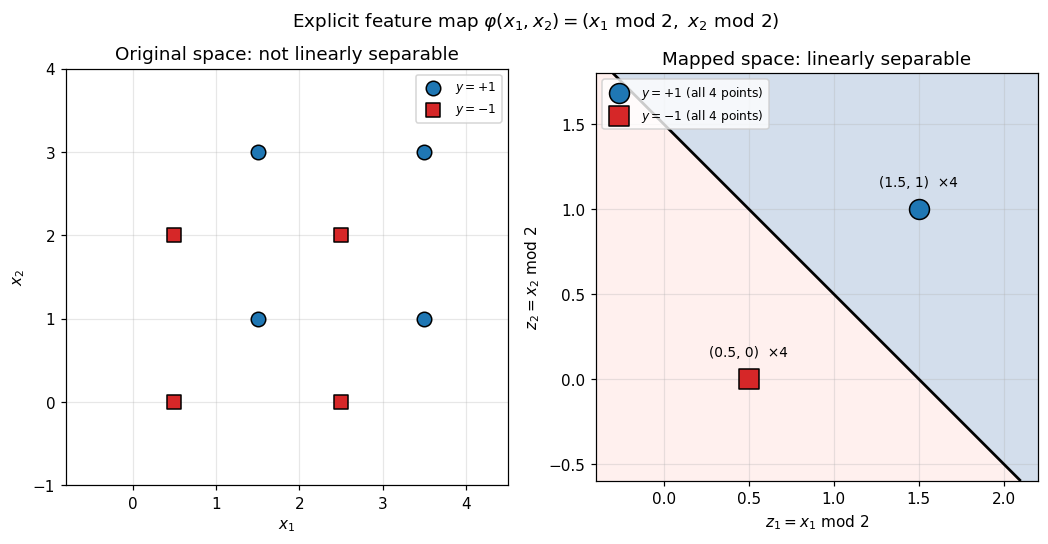

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.0))

ax = axes[0]
scatter_classes(ax, X2, y2)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Original space: not linearly separable")
ax.set_xlim(-0.8, 4.5); ax.set_ylim(-1.0, 4.0); ax.set_aspect("equal")
ax.legend(fontsize=8)

ax = axes[1]
gz1, gz2 = np.meshgrid(np.linspace(-0.4, 2.2, 300), np.linspace(-0.6, 1.8, 300))
gz = svm_mapped.decision_function(np.c_[gz1.ravel(), gz2.ravel()]).reshape(gz1.shape)
ax.contourf(gz1, gz2, gz, levels=[-1e9, 0, 1e9],
            colors=["mistyrose", "lightsteelblue"], alpha=0.55, zorder=0)
ax.contour(gz1, gz2, gz, levels=[0], colors="k", linewidths=1.8, zorder=2)
# All four points of each class coincide, so annotate the multiplicity.
for lab, colour, marker in [(1, "tab:blue", "o"), (-1, "tab:red", "s")]:
    pt = np.unique(Zmod[y2 == lab], axis=0)[0]
    ax.scatter(*pt, marker=marker, s=170, c=colour, edgecolor="k", zorder=5,
               label=f"$y = {lab:+d}$ (all 4 points)")
    ax.annotate(f"({pt[0]:g}, {pt[1]:g})  ×4", pt, textcoords="offset points",
                xytext=(0, 15), ha="center", fontsize=9)
ax.set_xlabel("$z_1 = x_1\\ \\mathrm{mod}\\ 2$")
ax.set_ylabel("$z_2 = x_2\\ \\mathrm{mod}\\ 2$")
ax.set_title("Mapped space: linearly separable")
ax.set_xlim(-0.4, 2.2); ax.set_ylim(-0.6, 1.8); ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Explicit feature map $\\varphi(x_1,x_2) = (x_1\\ \\mathrm{mod}\\ 2,\\ x_2\\ \\mathrm{mod}\\ 2)$")
save(fig, "p2_4_feature_map.png")
plt.show()

**Result.** The map sends all four positive points to $(1.5, 1)$ and all four negative
points to $(0.5, 0)$. A hard-margin linear SVM in the mapped space returns the rule
$z_1 + z_2 = 1.5$ with 100% training accuracy.

The map is deliberately lossy: it discards which period a point falls in and retains only
its position within the period. That is exactly the right thing to discard here, because
the label depends only on the position within the period and not on the period itself.
The price is that the map is not injective, so it would be the wrong choice for any problem
where absolute position matters.

## 2.5 Predicting four new samples

I apply $\varphi$ to each new point and classify with the rule $z_1 + z_2 \gtrless 1.5$
found in 2.4.

     x1     x2  z1 = x1 mod 2  z2 = x2 mod 2  z1 + z2  predicted y  predicted y (trig map)
-0.5000 1.0000         1.5000         1.0000   2.5000            1                       1
-0.5000 3.0000         1.5000         1.0000   2.5000            1                       1
 0.5000 4.0000         0.5000         0.0000   0.5000           -1                      -1
 2.5000 4.0000         0.5000         0.0000   0.5000           -1                      -1

The two feature maps agree on every point: True


saved -> figures\p2_5_new_predictions.png


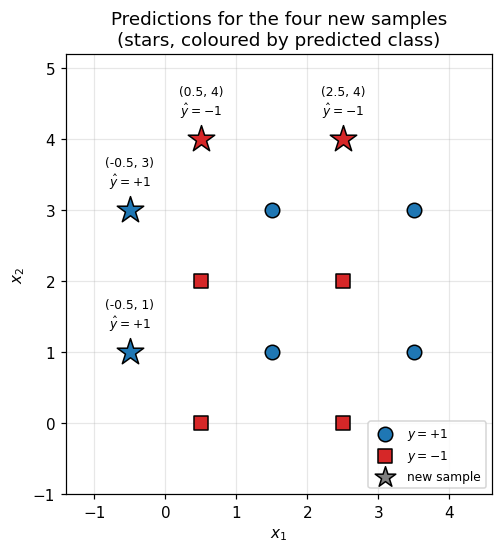

In [23]:
new_points = np.array([[-0.5, 1.0], [-0.5, 3.0], [0.5, 4.0], [2.5, 4.0]])
Znew = phi_mod(new_points)
pred_new = svm_mapped.predict(Znew)
pred_new_trig = SVC(kernel="linear", C=1e6).fit(phi_trig(X2), y2).predict(phi_trig(new_points))

result = pd.DataFrame({
    "x1": new_points[:, 0], "x2": new_points[:, 1],
    "z1 = x1 mod 2": Znew[:, 0], "z2 = x2 mod 2": Znew[:, 1],
    "z1 + z2": Znew.sum(axis=1),
    "predicted y": pred_new,
    "predicted y (trig map)": pred_new_trig,
})
print(result.to_string(index=False))
result.to_csv(RES_DIR / "p2_5_new_predictions.csv", index=False)
print(f"\nThe two feature maps agree on every point: "
      f"{np.array_equal(pred_new, pred_new_trig)}")

fig, ax = plt.subplots(figsize=(6.2, 5.2))
scatter_classes(ax, X2, y2)
for (a, b), pr in zip(new_points, pred_new):
    colour = "tab:blue" if pr == 1 else "tab:red"
    ax.scatter(a, b, marker="*", s=330, c=colour, edgecolor="k", zorder=6)
    ax.annotate(f"({a:g}, {b:g})\n$\\hat y = {pr:+d}$", (a, b),
                textcoords="offset points", xytext=(0, 16), ha="center", fontsize=8)
ax.scatter([], [], marker="*", s=200, c="grey", edgecolor="k", label="new sample")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Predictions for the four new samples\n(stars, coloured by predicted class)")
ax.set_xlim(-1.4, 4.6); ax.set_ylim(-1.0, 5.2)
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower right")
save(fig, "p2_5_new_predictions.png")
plt.show()

**Result.** $(-0.5, 1.0) \mapsto (1.5, 1.0)$ and $(-0.5, 3.0) \mapsto (1.5, 1.0)$, both
landing on the positive image, so both are predicted $\hat y = +1$. $(0.5, 4.0)$ and
$(2.5, 4.0)$ both map to $(0.5, 0.0)$ and are predicted $\hat y = -1$. The smooth map
$\tilde\varphi$ gives identical predictions.

These predictions are consistent extrapolations of the periodic pattern rather than
interpolations: $x_1 = -0.5$ and $x_2 = 4$ both lie outside the observed range. The map
assumes the period-2 structure continues beyond the training data, which is a strong
assumption that eight points cannot verify. A predictive claim of this kind should be
treated as conditional on that assumption holding.

## 2.6 The kernel trick and the kernel matrix

The kernel trick replaces the inner product $\varphi(\mathbf{x}_i)^{\top}\varphi(\mathbf{x}_j)$
by a kernel $K(\mathbf{x}_i, \mathbf{x}_j)$ evaluated directly on the original inputs, so
the feature map never has to be formed. For a training set of $n$ points the Gram (kernel)
matrix is $\mathbf{K} \in \mathbb{R}^{n \times n}$ with $K_{ij} = K(\mathbf{x}_i, \mathbf{x}_j)$.

I show the Gaussian (RBF) kernel
$K(\mathbf{x}, \mathbf{z}) = \exp(-\gamma\|\mathbf{x} - \mathbf{z}\|^2)$ with
$\gamma = 0.5$, and alongside it the kernel induced by the smooth feature map
$\tilde\varphi$ of 2.4, for comparison:

$$K_{\tilde\varphi}(\mathbf{x}, \mathbf{z})
= \tilde\varphi(\mathbf{x})^{\top}\tilde\varphi(\mathbf{z})
= \sin(\pi x_1)\sin(\pi z_1) + \cos(\pi x_2)\cos(\pi z_2).$$

I use $\tilde\varphi$ rather than the modulo map here because $\tilde\varphi$ maps both
classes onto images of equal norm $\sqrt{2}$, $(-1,-1)$ and $(+1,+1)$, so its inner products are directly
comparable across pairs. The modulo map sends the two classes to $(1.5, 1)$ and
$(0.5, 0)$, which have very different norms, and an un-centred inner product between
vectors of unequal length does not order pairs by similarity in the usual sense — the two
maps are equally valid for *classification*, but only $\tilde\varphi$ gives a Gram matrix
that can be read directly as a similarity structure. The points are ordered with the four
positives first so that any class block structure is visible.

In [24]:
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel

GAMMA = 0.5
K_rbf = rbf_kernel(X2, gamma=GAMMA)
K_phi = linear_kernel(phi_trig(X2))      # kernel induced by the smooth map

point_labels = [f"$x_{{{i+1}}}$ ({a:g},{b:g})\n$y={c:+d}$"
                for i, ((a, b), c) in enumerate(zip(X2, y2))]

print(f"RBF kernel matrix, gamma = {GAMMA} (rows/cols 1-4 are y=+1, 5-8 are y=-1):")
print(pd.DataFrame(K_rbf, index=range(1, 9), columns=range(1, 9)).round(3))
print("\nEigenvalues of K_rbf (all non-negative, so K is positive semi-definite):")
print(np.round(np.linalg.eigvalsh(K_rbf), 4))
pd.DataFrame(K_rbf, index=range(1, 9), columns=range(1, 9)).round(6).to_csv(
    RES_DIR / "p2_6_rbf_kernel_matrix.csv")

print(f"\nKernel induced by the smooth map phi_trig:")
print(pd.DataFrame(K_phi, index=range(1, 9), columns=range(1, 9)).round(3))
print(f"\n  within-class entries : {np.unique(np.round(K_phi[np.equal.outer(y2, y2)], 6))}")
print(f"  cross-class entries  : {np.unique(np.round(K_phi[~np.equal.outer(y2, y2)], 6))}")
same_beats_other = all(
    K_phi[i, j] > K_phi[i, k]
    for i in range(8) for j in range(8) for k in range(8)
    if y2[j] == y2[i] and y2[k] != y2[i])
print(f"  every point strictly more similar to its own class: {same_beats_other}")
pd.DataFrame(K_phi, index=range(1, 9), columns=range(1, 9)).round(6).to_csv(
    RES_DIR / "p2_6_feature_map_kernel_matrix.csv")

RBF kernel matrix, gamma = 0.5 (rows/cols 1-4 are y=+1, 5-8 are y=-1):
       1      2      3      4      5      6      7      8
1 1.0000 0.1350 0.1350 0.0180 0.3680 0.3680 0.3680 0.3680
2 0.1350 1.0000 0.0180 0.1350 0.0070 0.3680 0.0070 0.3680
3 0.1350 0.0180 1.0000 0.1350 0.0070 0.0070 0.3680 0.3680
4 0.0180 0.1350 0.1350 1.0000 0.0000 0.0070 0.0070 0.3680
5 0.3680 0.0070 0.0070 0.0000 1.0000 0.1350 0.1350 0.0180
6 0.3680 0.3680 0.0070 0.0070 0.1350 1.0000 0.0180 0.1350
7 0.3680 0.0070 0.3680 0.0070 0.1350 0.0180 1.0000 0.1350
8 0.3680 0.3680 0.3680 0.3680 0.0180 0.1350 0.1350 1.0000

Eigenvalues of K_rbf (all non-negative, so K is positive semi-definite):
[0.2802 0.6041 0.6205 0.6297 0.9243 1.3428 1.3658 2.2326]

Kernel induced by the smooth map phi_trig:
        1       2       3       4       5       6       7       8
1  2.0000  2.0000  2.0000  2.0000 -2.0000 -2.0000 -2.0000 -2.0000
2  2.0000  2.0000  2.0000  2.0000 -2.0000 -2.0000 -2.0000 -2.0000
3  2.0000  2.0000  2.0000  2.0000

saved -> figures\p2_6_kernel_matrices.png


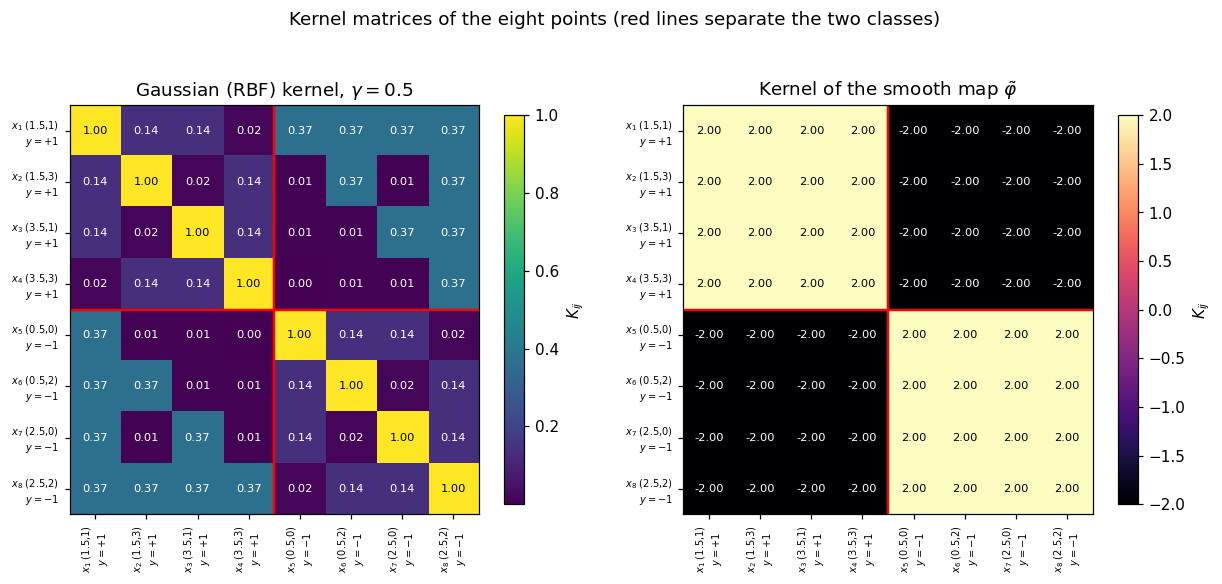

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))

for ax, K, title, cmap in [
        (axes[0], K_rbf, f"Gaussian (RBF) kernel, $\\gamma = {GAMMA}$", "viridis"),
        (axes[1], K_phi, "Kernel of the smooth map $\\tilde{\\varphi}$", "magma")]:
    im = ax.imshow(K, cmap=cmap)
    ax.set_xticks(range(8)); ax.set_xticklabels(point_labels, fontsize=6.5, rotation=90)
    ax.set_yticks(range(8)); ax.set_yticklabels(point_labels, fontsize=6.5)
    for i in range(8):
        for j in range(8):
            val = K[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if val < K.max() * 0.55 else "black")
    # Mark the class boundary between the 4th and 5th point.
    ax.axhline(3.5, color="red", lw=1.6); ax.axvline(3.5, color="red", lw=1.6)
    ax.set_title(title)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.82, label="$K_{ij}$")

fig.suptitle("Kernel matrices of the eight points (red lines separate the two classes)")
save(fig, "p2_6_kernel_matrices.png")
plt.show()

**Reading the kernel matrices.** The RBF matrix has ones on the diagonal, since
$K(\mathbf{x}, \mathbf{x}) = 1$, and decays with squared distance. Its eigenvalues are all
positive, confirming it is a valid positive semi-definite kernel. But the class blocks
marked by the red lines are *not* uniformly bright: several within-class entries are close
to zero (for example $K_{14} = 0.018$, between $(1.5, 3.0)$ and $(3.5, 1.0)$, which are
far apart), while several cross-class entries are comparatively large (every entry in the
first column of the lower-left block is 0.368). This is the same interleaving that defeated
the linear SVM, now expressed as similarities: with $\gamma = 0.5$ the RBF kernel measures
plain geometric proximity, and geometric proximity does not track the label here. An RBF
SVM would still classify the training set correctly, because a sufficiently large $\gamma$
lets it fit almost anything, but it would be memorising rather than exploiting structure.

The kernel induced by $\tilde\varphi$ shows what a well-matched kernel looks like: an exact
$4\times4$ block structure with $K_{ij} = +2$ for every pair in the same class and
$K_{ij} = -2$ for every pair in different classes. Because both class images have the same
norm, $\sqrt{2}$, these inner products are directly comparable, and every point is strictly more
similar to all four members of its own class than to any member of the other — the
condition that fails for the Gaussian kernel. That is exactly why a linear classifier
separates the mapped data perfectly.

The contrast makes the practical point of the kernel trick concrete. The choice of kernel
encodes an assumption about which points should count as similar, and a kernel matched to
the structure of the problem does far more work than a generic one. It is worth adding that
a Gram matrix should be read with the norms of the feature vectors in mind: an un-centred
inner product mixes similarity of direction with magnitude, so a block of large values does
not by itself imply within-class similarity unless the images are comparably scaled, as
they are here.

---
# Problem 3 — Decision trees, bagging, random forests and boosting (35 points)

Throughout, $Y = 1$ denotes a severe delay and $Y = 0$ a non-severe delay.

## 3.1 Decision-tree splitting criteria

The node holds 12 historical incidents, 7 severe and 5 non-severe. With
$H(S) = -\sum_k p_k\log_2 p_k$ and $G(S) = 1 - \sum_k p_k^2$, a binary split into children
$S_L, S_R$ is scored by

$$\text{IG} = H(S) - \frac{|S_L|}{|S|}H(S_L) - \frac{|S_R|}{|S|}H(S_R),
\qquad
\Delta G = G(S) - \frac{|S_L|}{|S|}G(S_L) - \frac{|S_R|}{|S|}G(S_R).$$

In [26]:
def gini(counts):
    c = np.asarray(counts, dtype=float)
    if c.sum() == 0:
        return 0.0
    p = c / c.sum()
    return float(1 - (p ** 2).sum())


PARENT = (7, 5)                      # (severe, non-severe)
SPLITS = {
    "A: current_delay_min >= 10": {"left": (5, 1), "right": (2, 4)},
    "B: major_incident = yes":    {"left": (5, 0), "right": (2, 5)},
}
n_parent = sum(PARENT)

print("--- Part 1: parent node ---")
print(f"parent = {PARENT[0]} severe, {PARENT[1]} non-severe  (n = {n_parent})")
print(f"  p(severe) = {PARENT[0]}/{n_parent} = {PARENT[0]/n_parent:.6f}")
print(f"  H(parent) = {entropy(PARENT):.6f} bits")
print(f"  G(parent) = {gini(PARENT):.6f}")

rows = []
for name, ch in SPLITS.items():
    nL, nR = sum(ch["left"]), sum(ch["right"])
    wL, wR = nL / n_parent, nR / n_parent
    wH = wL * entropy(ch["left"]) + wR * entropy(ch["right"])
    wG = wL * gini(ch["left"]) + wR * gini(ch["right"])
    rows.append({
        "split": name, "n_left": nL, "n_right": nR,
        "H(left)": entropy(ch["left"]), "H(right)": entropy(ch["right"]),
        "weighted H": wH, "information gain": entropy(PARENT) - wH,
        "G(left)": gini(ch["left"]), "G(right)": gini(ch["right"]),
        "weighted G": wG, "Gini reduction": gini(PARENT) - wG,
    })
split_table = pd.DataFrame(rows).set_index("split")

print("\n--- Part 2: entropy and information gain ---")
print(split_table[["H(left)", "H(right)", "weighted H", "information gain"]].round(6))
print("\n--- Part 3: Gini impurity and reduction ---")
print(split_table[["G(left)", "G(right)", "weighted G", "Gini reduction"]].round(6))
print("\n--- Part 4: which split wins ---")
print(f"highest information gain: {split_table['information gain'].idxmax()}")
print(f"highest Gini reduction:   {split_table['Gini reduction'].idxmax()}")
split_table.round(6).to_csv(RES_DIR / "p3_1_split_criteria.csv")

--- Part 1: parent node ---
parent = 7 severe, 5 non-severe  (n = 12)
  p(severe) = 7/12 = 0.583333
  H(parent) = 0.979869 bits
  G(parent) = 0.486111

--- Part 2: entropy and information gain ---
                            H(left)  H(right)  weighted H  information gain
split                                                                      
A: current_delay_min >= 10   0.6500    0.9183      0.7842            0.1957
B: major_incident = yes     -0.0000    0.8631      0.5035            0.4764

--- Part 3: Gini impurity and reduction ---
                            G(left)  G(right)  weighted G  Gini reduction
split                                                                    
A: current_delay_min >= 10   0.2778    0.4444      0.3611          0.1250
B: major_incident = yes      0.0000    0.4082      0.2381          0.2480

--- Part 4: which split wins ---
highest information gain: B: major_incident = yes
highest Gini reduction:   B: major_incident = yes


saved -> figures\p3_1_split_comparison.png


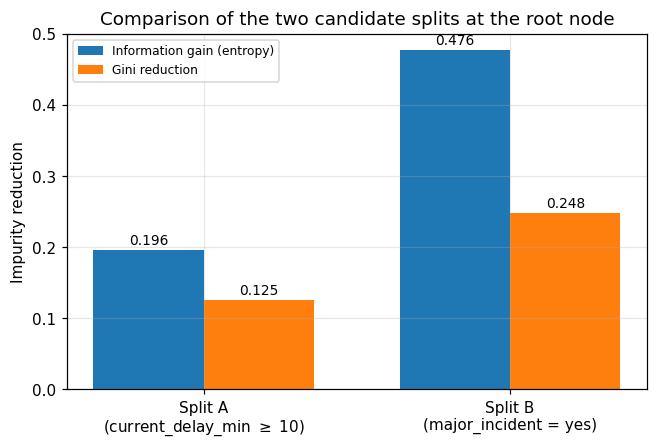

In [27]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
pos = np.arange(len(split_table))
width = 0.36
ax.bar(pos - width / 2, split_table["information gain"], width,
       label="Information gain (entropy)", color="tab:blue")
ax.bar(pos + width / 2, split_table["Gini reduction"], width,
       label="Gini reduction", color="tab:orange")
for k, (ig, dg) in enumerate(zip(split_table["information gain"],
                                 split_table["Gini reduction"])):
    ax.text(k - width / 2, ig + 0.008, f"{ig:.3f}", ha="center", fontsize=9)
    ax.text(k + width / 2, dg + 0.008, f"{dg:.3f}", ha="center", fontsize=9)
ax.set_xticks(pos); ax.set_xticklabels(["Split A\n(current_delay_min $\\geq$ 10)",
                                        "Split B\n(major_incident = yes)"])
ax.set_ylabel("Impurity reduction")
ax.set_title("Comparison of the two candidate splits at the root node")
ax.legend(fontsize=8)
save(fig, "p3_1_split_comparison.png")
plt.show()

**Answers.**

1. The parent node is 7 severe and 5 non-severe, so $p_1 = 7/12 = 0.5833$ and
   $p_0 = 5/12 = 0.4167$, giving $H = 0.979869$ bits and $G = 0.486111$.
2. Split A yields a weighted child entropy of $0.784159$ and $\text{IG}_A = 0.195710$
   bits; Split B yields $0.503487$ and $\text{IG}_B = 0.476382$ bits.
3. Split A yields a weighted child Gini of $0.361111$ and $\Delta G_A = 0.125000$;
   Split B yields $0.238095$ and $\Delta G_B = 0.248016$.
4. **Split B should be selected first**, because it gives both the larger information gain
   ($0.476382$ against $0.195710$ bits) and the larger Gini reduction ($0.248016$ against
   $0.125000$), so the two criteria agree. In control-centre terms, `major_incident = yes`
   isolates a completely pure group of severe delays, which makes it an immediately
   actionable first split that can trigger escalation without waiting to see how the delay
   develops.

   *(The problem sheet asks for one or two sentences, so the answer above is kept to two.)*

## 3.2 Bootstrap sampling and out-of-bag observations

A bootstrap sample draws $n$ observations from the training set with replacement, each draw
uniform over the $n$ original observations and independent of the others.

In [28]:
print("--- Part 1: probability for a fixed observation i ---")
print("A single draw picks observation i with probability 1/n, so it misses i with")
print("probability 1 - 1/n. The n draws are independent, hence")
print("    P(i never selected) = (1 - 1/n)^n")
print("    P(i selected at least once) = 1 - (1 - 1/n)^n\n")

print("--- Part 2: limits as n -> infinity ---")
for n in [10, 100, 1000, 10000, 100000]:
    q = (1 - 1 / n) ** n
    print(f"  n = {n:>6,}:  P(not selected) = {q:.6f},  P(selected) = {1 - q:.6f}")
print(f"\n  limit:      exp(-1)     = {np.exp(-1):.6f},  1 - exp(-1)  = {1 - np.exp(-1):.6f}")
print("  (using (1 - 1/n)^n = exp[n ln(1 - 1/n)] -> exp(-1))")

print("\n--- Part 3: n = 5000 ---")
n = 5000
q = (1 - 1 / n) ** n
print(f"  P(not selected)     = {q:.6f}")
print(f"  E[unique in sample] = n(1 - (1-1/n)^n) = {n * (1 - q):.4f}  ({100*(1-q):.2f}% of the data)")
print(f"  E[out-of-bag]       = n(1-1/n)^n       = {n * q:.4f}  ({100*q:.2f}% of the data)")
print(f"  check: {n * (1 - q):.4f} + {n * q:.4f} = {n * (1 - q) + n * q:.1f}")

print("\n--- Part 4: five distinct incidents {A, B, C, D, E}, sample of size 5 ---")
print(f"  ordered bootstrap samples   = 5^5           = {5 ** 5}")
print(f"  unordered (multiplicities)  = C(5 + 5 - 1, 5) = C(9,5) = {comb(9, 5)}")

--- Part 1: probability for a fixed observation i ---
A single draw picks observation i with probability 1/n, so it misses i with
probability 1 - 1/n. The n draws are independent, hence
    P(i never selected) = (1 - 1/n)^n
    P(i selected at least once) = 1 - (1 - 1/n)^n

--- Part 2: limits as n -> infinity ---
  n =     10:  P(not selected) = 0.348678,  P(selected) = 0.651322
  n =    100:  P(not selected) = 0.366032,  P(selected) = 0.633968
  n =  1,000:  P(not selected) = 0.367695,  P(selected) = 0.632305
  n = 10,000:  P(not selected) = 0.367861,  P(selected) = 0.632139
  n = 100,000:  P(not selected) = 0.367878,  P(selected) = 0.632122

  limit:      exp(-1)     = 0.367879,  1 - exp(-1)  = 0.632121
  (using (1 - 1/n)^n = exp[n ln(1 - 1/n)] -> exp(-1))

--- Part 3: n = 5000 ---
  P(not selected)     = 0.367843
  E[unique in sample] = n(1 - (1-1/n)^n) = 3160.7867  (63.22% of the data)
  E[out-of-bag]       = n(1-1/n)^n       = 1839.2133  (36.78% of the data)
  check: 3160.7867 + 1

simulation over 2000 bootstrap samples of size n = 5000
  mean unique observations = 3159.55  (theory 3160.79)
  mean out-of-bag          = 1840.45  (theory 1839.21)


saved -> figures\p3_2_bootstrap_probabilities.png


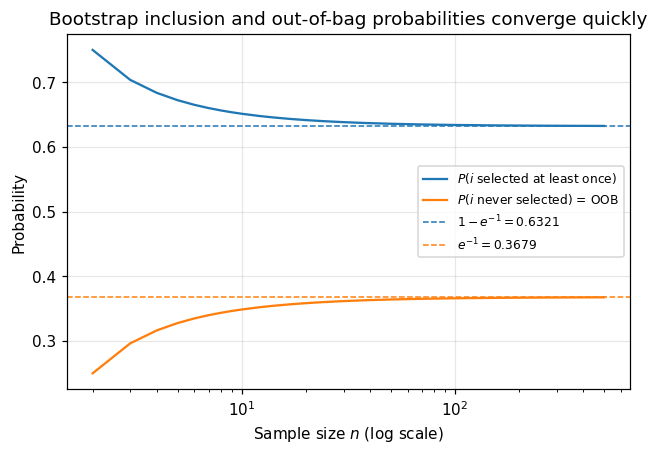

In [29]:
# Empirical confirmation of the n = 5000 result by direct simulation.
rng_boot = np.random.default_rng(RANDOM_STATE)
n, n_reps = 5000, 2000
uniques = np.array([len(np.unique(rng_boot.integers(0, n, n))) for _ in range(n_reps)])
print(f"simulation over {n_reps} bootstrap samples of size n = {n}")
print(f"  mean unique observations = {uniques.mean():.2f}  (theory {n * (1 - (1-1/n)**n):.2f})")
print(f"  mean out-of-bag          = {n - uniques.mean():.2f}  (theory {n * (1-1/n)**n:.2f})")

grid = np.arange(2, 501)
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot(grid, 1 - (1 - 1 / grid) ** grid, color="tab:blue", label="$P(i$ selected at least once$)$")
ax.plot(grid, (1 - 1 / grid) ** grid, color="tab:orange", label="$P(i$ never selected$)$ = OOB")
ax.axhline(1 - np.exp(-1), color="tab:blue", ls="--", lw=1, label="$1 - e^{-1} = 0.6321$")
ax.axhline(np.exp(-1), color="tab:orange", ls="--", lw=1, label="$e^{-1} = 0.3679$")
ax.set_xscale("log")
ax.set_xlabel("Sample size $n$ (log scale)")
ax.set_ylabel("Probability")
ax.set_title("Bootstrap inclusion and out-of-bag probabilities converge quickly")
ax.legend(fontsize=8)
save(fig, "p3_2_bootstrap_probabilities.png")
plt.show()

**Answers.**

1. Each of the $n$ independent draws selects observation $i$ with probability $1/n$, so it
   fails to select $i$ with probability $1 - 1/n$. Across $n$ draws,
   $P(i \notin \text{sample}) = (1 - 1/n)^n$ and
   $P(i \in \text{sample}) = 1 - (1 - 1/n)^n$.
2. Since $n\ln(1 - 1/n) \to -1$, the limits are $e^{-1} \approx 0.3679$ and
   $1 - e^{-1} \approx 0.6321$. In words: however large the dataset, a bootstrap sample
   contains only about 63% of the distinct observations and leaves roughly 37%
   out-of-bag. Convergence is fast — the value is already 0.3660 at $n = 100$. This is what
   makes bagged trees differ from one another, and it supplies a free validation set: each
   tree can be scored on the third of the data it never saw, which is the basis of the OOB
   error estimate.
3. For $n = 5000$: $P(\text{not selected}) = 0.367843$, so the expected number of unique
   observations is $5000 \times 0.632157 = 3160.79$ and the expected number of out-of-bag
   observations is $5000 \times 0.367843 = 1839.21$. A simulation of 2000 bootstrap samples
   reproduces these figures.
4. Ordered samples: each of the 5 draws has 5 possibilities, giving $5^5 = 3125$. If only
   the multiplicities matter, the count is the number of multisets of size 5 from 5 types,
   $\binom{5 + 5 - 1}{5} = \binom{9}{5} = 126$.

## 3.3 Ensemble voting and boosting intuition

For $M$ independent classifiers each correct with probability $p$, the number correct is
$X \sim \text{Bin}(M, p)$ and a majority vote is right when $X > M/2$. Gradient boosting
instead fits each new learner to the residuals of the current model and adds it with a
learning rate $\eta$: $\hat y^{(m)} = \hat y^{(m-1)} + \eta\, h_m(x)$.

In [30]:
print("--- Part 1: majority vote of five classifiers, p = 0.65 ---")
M, p_correct = 5, 0.65
terms = {k: comb(M, k) * p_correct ** k * (1 - p_correct) ** (M - k) for k in range(3, M + 1)}
for k, v in terms.items():
    print(f"  P(exactly {k} correct) = C(5,{k}) * 0.65^{k} * 0.35^{M-k} = {v:.6f}")
p_ensemble = sum(terms.values())
print(f"  P(majority correct) = {p_ensemble:.6f}")
print(f"  scipy check (binom.sf(2, 5, 0.65)) = {stats.binom.sf(2, M, p_correct):.6f}")
print(f"  improvement over a single classifier: {p_ensemble:.4f} - {p_correct:.2f} "
      f"= +{p_ensemble - p_correct:.4f}")

print("\n--- Part 2: one gradient boosting update ---")
y_obs = np.array([5.0, 9.0, 14.0, 18.0])
y_hat0 = np.array([8.0, 8.0, 8.0, 8.0])
h1 = np.array([-2.0, 1.0, 5.0, 5.0])
eta = 0.2
residuals = y_obs - y_hat0
y_hat1 = y_hat0 + eta * h1

boost = pd.DataFrame({
    "y": y_obs, "y_hat(0)": y_hat0, "residual r = y - y_hat(0)": residuals,
    "h1(x)": h1, "eta * h1(x)": eta * h1, "y_hat(1)": y_hat1,
    "new residual": y_obs - y_hat1,
}, index=[f"i = {i}" for i in range(1, 5)])
print(boost.round(4))
print(f"\n  SSE before = {np.sum(residuals ** 2):.2f}")
print(f"  SSE after  = {np.sum((y_obs - y_hat1) ** 2):.2f}")
boost.round(4).to_csv(RES_DIR / "p3_3_boosting_update.csv")

--- Part 1: majority vote of five classifiers, p = 0.65 ---
  P(exactly 3 correct) = C(5,3) * 0.65^3 * 0.35^2 = 0.336416
  P(exactly 4 correct) = C(5,4) * 0.65^4 * 0.35^1 = 0.312386
  P(exactly 5 correct) = C(5,5) * 0.65^5 * 0.35^0 = 0.116029
  P(majority correct) = 0.764831
  scipy check (binom.sf(2, 5, 0.65)) = 0.764831
  improvement over a single classifier: 0.7648 - 0.65 = +0.1148

--- Part 2: one gradient boosting update ---
            y  y_hat(0)  residual r = y - y_hat(0)   h1(x)  eta * h1(x)  y_hat(1)  new residual
i = 1  5.0000    8.0000                    -3.0000 -2.0000      -0.4000    7.6000       -2.6000
i = 2  9.0000    8.0000                     1.0000  1.0000       0.2000    8.2000        0.8000
i = 3 14.0000    8.0000                     6.0000  5.0000       1.0000    9.0000        5.0000
i = 4 18.0000    8.0000                    10.0000  5.0000       1.0000    9.0000        9.0000

  SSE before = 146.00
  SSE after  = 113.40


saved -> figures\p3_3_majority_vote.png


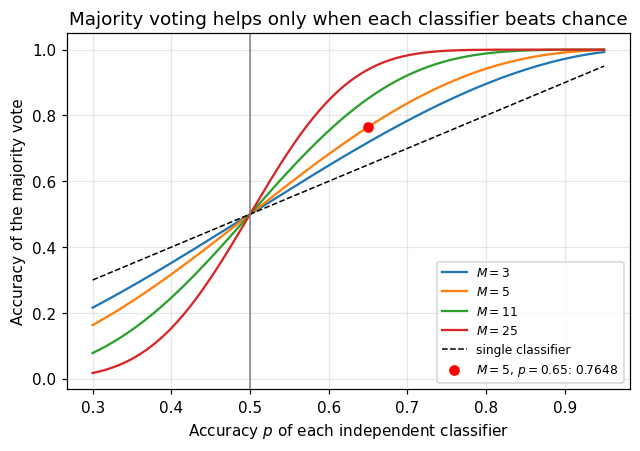

In [31]:
# How the majority-vote advantage depends on p and on the number of classifiers.
fig, ax = plt.subplots(figsize=(6.6, 4.2))
p_grid = np.linspace(0.3, 0.95, 300)
for M_ in [3, 5, 11, 25]:
    ax.plot(p_grid, stats.binom.sf((M_ - 1) // 2, M_, p_grid), label=f"$M = {M_}$")
ax.plot(p_grid, p_grid, "k--", lw=1, label="single classifier")
ax.scatter([0.65], [p_ensemble], color="red", zorder=5,
           label=f"$M=5$, $p=0.65$: {p_ensemble:.4f}")
ax.axvline(0.5, color="grey", lw=1)
ax.set_xlabel("Accuracy $p$ of each independent classifier")
ax.set_ylabel("Accuracy of the majority vote")
ax.set_title("Majority voting helps only when each classifier beats chance")
ax.legend(fontsize=8)
save(fig, "p3_3_majority_vote.png")
plt.show()

**Answers.**

1. $P(\text{majority correct}) = \sum_{k=3}^{5}\binom{5}{k}0.65^k 0.35^{5-k}
   = 0.336416 + 0.312386 + 0.116029 = \mathbf{0.764831}$. Combining five weak classifiers
   lifts accuracy from 65% to 76.5%. The curve shows the condition for this to work: the
   vote improves on the individual only when $p > 0.5$, and below that adding classifiers
   makes matters worse. It also depends on independence, which real ensemble members never
   fully satisfy — a random forest approximates it through bootstrap sampling and random
   feature subsets, and the realised gain is smaller than this idealised calculation.
2. The residuals are $r = (-3, 1, 6, 10)$. With $\eta = 0.2$ the update is
   $\hat y^{(1)} = \hat y^{(0)} + 0.2\,h_1(x) = (7.6,\ 8.2,\ 9.0,\ 9.0)$. Every prediction
   moves in the direction of its residual but only a fifth of the way, which is the point of
   shrinkage: the sum of squared errors falls from 146.0 to 113.4 in one step rather than
   jumping to a possibly over-fitted solution. The two largest residuals (6 and 10) remain
   substantially unresolved, so many further rounds would be needed — this is the usual
   trade-off in which a small learning rate requires more trees but generalises better.

## 3.4 Coding exercise — predicting severe delays

The dataset is generated exactly as specified in the problem sheet. Six operational
features describe each incident, and `severe_delay` is a thresholded noisy score built from
main effects and interactions, so a good model must capture interactions such as
`peak_hour AND rain`.

In [32]:
rng = np.random.default_rng(42)
n = 1200

df = pd.DataFrame({
    "peak_hour": rng.binomial(1, 0.45, n),
    "rain": rng.binomial(1, 0.30, n),
    "major_incident": rng.binomial(1, 0.12, n),
    "critical_hub": rng.binomial(1, 0.25, n),
    "current_delay_min": np.clip(rng.normal(5, 4, n), 0, None),
    "passenger_load": rng.uniform(0.2, 1.2, n),
})

score = (
    1.0 * (df["current_delay_min"] > 8)
    + 1.0 * (df["peak_hour"] & df["rain"])
    + 1.5 * df["major_incident"]
    + 0.9 * (df["critical_hub"] & (df["passenger_load"] > 0.8))
    + 0.8 * (df["rain"] & (df["current_delay_min"] > 5))
    + 0.6 * (df["peak_hour"] & (df["passenger_load"] > 0.9))
    + rng.normal(0, 0.7, n)
)

df["severe_delay"] = (score > 1.5).astype(int)

print(f"generated dataset: {df.shape}")
print(df.head())
print("\nmissing values:", int(df.isna().sum().sum()))
print(df.describe().T[["mean", "std", "min", "max"]].round(3))

generated dataset: (1200, 7)
   peak_hour  rain  major_incident  critical_hub  current_delay_min  passenger_load  severe_delay
0          1     0               0             0             2.5071          0.3329             0
1          0     0               0             0             2.5144          1.0784             0
2          1     1               0             0             2.4035          1.0386             1
3          1     1               1             0             2.1642          1.0711             1
4          0     0               0             1             0.0000          0.3517             0

missing values: 0
                    mean    std    min     max
peak_hour         0.4560 0.4980 0.0000  1.0000
rain              0.3020 0.4590 0.0000  1.0000
major_incident    0.1190 0.3240 0.0000  1.0000
critical_hub      0.2320 0.4230 0.0000  1.0000
current_delay_min 5.2450 3.6180 0.0000 17.9650
passenger_load    0.6950 0.2850 0.2000  1.2000
severe_delay      0.2340 0.4240 0.0

### 3.4.1 Class balance

                count  share
severe_delay                
0 = non-severe    919 0.7658
1 = severe        281 0.2342

imbalance ratio (non-severe : severe) = 3.27 : 1
a majority-class baseline would score 0.7658 accuracy while never predicting a severe delay


saved -> figures\p3_4_class_balance.png


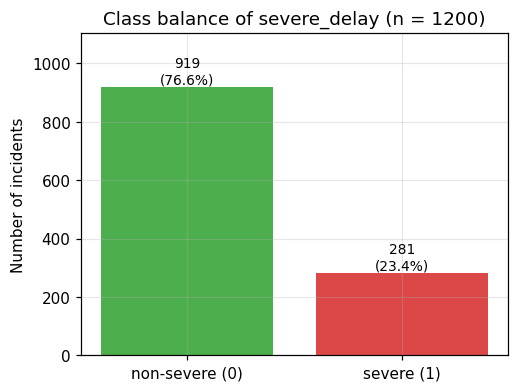

In [33]:
counts = df["severe_delay"].value_counts().sort_index()
balance = pd.DataFrame({
    "count": counts,
    "share": counts / len(df),
}).rename(index={0: "0 = non-severe", 1: "1 = severe"})
print(balance.round(4))
print(f"\nimbalance ratio (non-severe : severe) = {counts[0] / counts[1]:.2f} : 1")
print(f"a majority-class baseline would score {counts[0] / len(df):.4f} accuracy "
      f"while never predicting a severe delay")
balance.round(4).to_csv(RES_DIR / "p3_4_class_balance.csv")

fig, ax = plt.subplots(figsize=(5.0, 3.8))
bars = ax.bar(["non-severe (0)", "severe (1)"], counts.values,
              color=["tab:green", "tab:red"], alpha=0.85)
for bar, c in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 12,
            f"{c}\n({c/len(df):.1%})", ha="center", fontsize=9)
ax.set_ylabel("Number of incidents")
ax.set_title("Class balance of severe_delay (n = 1200)")
ax.set_ylim(0, counts.max() * 1.2)
save(fig, "p3_4_class_balance.png")
plt.show()

**Class balance.** 919 incidents (76.6%) are non-severe and 281 (23.4%) are severe, an
imbalance of roughly 3.3 to 1.

Class balance matters in transportation applications for two connected reasons. First, it
makes accuracy misleading as a headline metric: a model that predicts "non-severe" for every
incident scores 76.6% accuracy while providing no operational value whatsoever, so accuracy
must be read alongside recall, F1 and ROC-AUC. Second, and more importantly, the rare class
is the one that matters. Severe delays are what trigger replacement buses, staff callouts
and passenger information — the whole reason the control centre wants a model. Training
algorithms that minimise overall error will, left alone, sacrifice performance on the
minority class to gain on the majority, which is precisely the wrong trade for this
application. The imbalance here is moderate, so I train on the data as generated (as the
problem sheet specifies) rather than reweighting, but the metric choice and the threshold
discussion in 3.4.5 both take it into account.

### 3.4.2 Decision tree with `max_depth=3`

In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

FEATURES = [c for c in df.columns if c != "severe_delay"]
X3, y3 = df[FEATURES], df["severe_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.30, stratify=y3, random_state=RANDOM_STATE)

print(f"train: {X_train.shape[0]} rows, severe share = {y_train.mean():.4f}")
print(f"test : {X_test.shape[0]} rows, severe share = {y_test.mean():.4f}")
print("stratification preserved the class proportions in both partitions")

train: 840 rows, severe share = 0.2345
test : 360 rows, severe share = 0.2333
stratification preserved the class proportions in both partitions


In [35]:
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)

root_feature = FEATURES[tree.tree_.feature[0]]
root_threshold = tree.tree_.threshold[0]
print("FIRST SPLIT OF THE TREE")
print(f"  rule       : {root_feature} <= {root_threshold:.4f} "
      f"(left child) versus > {root_threshold:.4f} (right child)")
print(f"  node size  : {tree.tree_.n_node_samples[0]} training incidents")
print(f"  root Gini  : {tree.tree_.impurity[0]:.4f}")
left, right = tree.tree_.children_left[0], tree.tree_.children_right[0]
for side, node in [("left  (<=)", left), ("right (> )", right)]:
    val = tree.tree_.value[node][0]
    print(f"  {side}: n = {tree.tree_.n_node_samples[node]:>3d}, "
          f"Gini = {tree.tree_.impurity[node]:.4f}, "
          f"severe share = {val[1] / val.sum():.4f}")
print("\nFull tree structure:")
print(export_text(tree, feature_names=FEATURES, decimals=3))

FIRST SPLIT OF THE TREE
  rule       : current_delay_min <= 7.4684 (left child) versus > 7.4684 (right child)
  node size  : 840 training incidents
  root Gini  : 0.3590
  left  (<=): n = 628, Gini = 0.2433, severe share = 0.1417
  right (> ): n = 212, Gini = 0.4998, severe share = 0.5094

Full tree structure:
|--- current_delay_min <= 7.468
|   |--- major_incident <= 0.500
|   |   |--- rain <= 0.500
|   |   |   |--- class: 0
|   |   |--- rain >  0.500
|   |   |   |--- class: 0
|   |--- major_incident >  0.500
|   |   |--- rain <= 0.500
|   |   |   |--- class: 0
|   |   |--- rain >  0.500
|   |   |   |--- class: 1
|--- current_delay_min >  7.468
|   |--- rain <= 0.500
|   |   |--- major_incident <= 0.500
|   |   |   |--- class: 0
|   |   |--- major_incident >  0.500
|   |   |   |--- class: 1
|   |--- rain >  0.500
|   |   |--- peak_hour <= 0.500
|   |   |   |--- class: 1
|   |   |--- peak_hour >  0.500
|   |   |   |--- class: 1



saved -> figures\p3_4_decision_tree.png


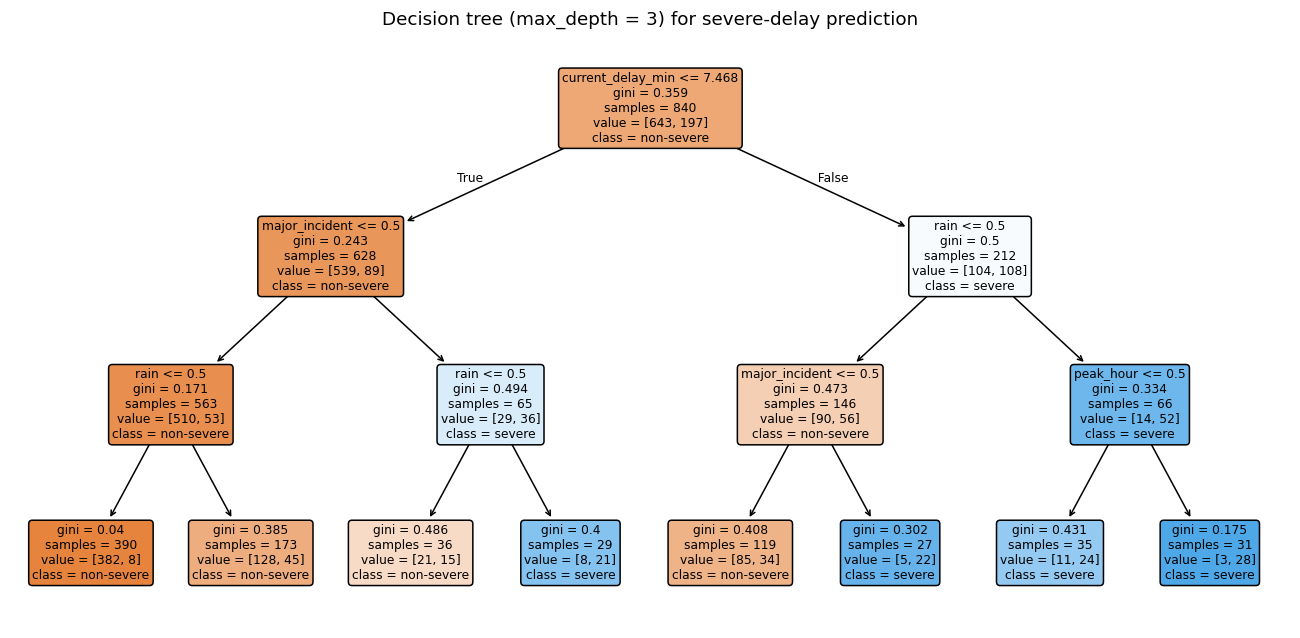

In [36]:
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, feature_names=FEATURES, class_names=["non-severe", "severe"],
          filled=True, rounded=True, fontsize=8, impurity=True, proportion=False, ax=ax)
ax.set_title("Decision tree (max_depth = 3) for severe-delay prediction")
save(fig, "p3_4_decision_tree.png")
plt.show()

### 3.4.3 Random forest and gradient boosting, compared on the same test set

In [37]:
models = {
    "Decision tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                                    max_depth=3, random_state=RANDOM_STATE),
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
}

metrics, probabilities, confusion = {}, {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    probabilities[name] = y_prob
    confusion[name] = confusion_matrix(y_test, y_pred)
    metrics[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }

results = pd.DataFrame(metrics).T
print("TEST-SET PERFORMANCE (360 held-out incidents)")
print(results.round(4))
results.round(4).to_csv(RES_DIR / "p3_4_test_metrics.csv")

print("\nConfusion matrices  [[TN, FP], [FN, TP]]:")
for name, cm in confusion.items():
    tn, fp, fn, tp = cm.ravel()
    print(f"  {name:26s} {cm.tolist()}   "
          f"TN={tn} FP={fp} FN={fn} TP={tp}")

TEST-SET PERFORMANCE (360 held-out incidents)
                           accuracy  precision  recall  F1-score  ROC-AUC
Decision tree                0.8472     0.8537  0.4167    0.5600   0.8469
Random forest                0.8528     0.7627  0.5357    0.6294   0.8972
Gradient boosting            0.8583     0.7797  0.5476    0.6434   0.8810
Baseline (majority class)    0.7667     0.0000  0.0000    0.0000   0.5000

Confusion matrices  [[TN, FP], [FN, TP]]:
  Decision tree              [[270, 6], [49, 35]]   TN=270 FP=6 FN=49 TP=35
  Random forest              [[262, 14], [39, 45]]   TN=262 FP=14 FN=39 TP=45
  Gradient boosting          [[263, 13], [38, 46]]   TN=263 FP=13 FN=38 TP=46
  Baseline (majority class)  [[276, 0], [84, 0]]   TN=276 FP=0 FN=84 TP=0


In [38]:
# Cross-validated ROC-AUC on the TRAINING data only, to check the test-set
# ranking is not an artefact of one particular split. The test set is not touched.
print("5-fold cross-validated ROC-AUC on the training set:")
for name in ["Decision tree", "Random forest", "Gradient boosting"]:
    cv = cross_val_score(models[name], X_train, y_train, cv=5, scoring="roc_auc")
    print(f"  {name:20s} {cv.mean():.4f} +/- {cv.std():.4f}   folds: {np.round(cv, 4)}")

5-fold cross-validated ROC-AUC on the training set:
  Decision tree        0.8535 +/- 0.0122   folds: [0.8334 0.868  0.8584 0.8465 0.8613]


  Random forest        0.9194 +/- 0.0093   folds: [0.9098 0.9322 0.9098 0.917  0.9283]


  Gradient boosting    0.9141 +/- 0.0078   folds: [0.9052 0.9276 0.9113 0.9093 0.9173]


saved -> figures\p3_4_confusion_and_roc.png


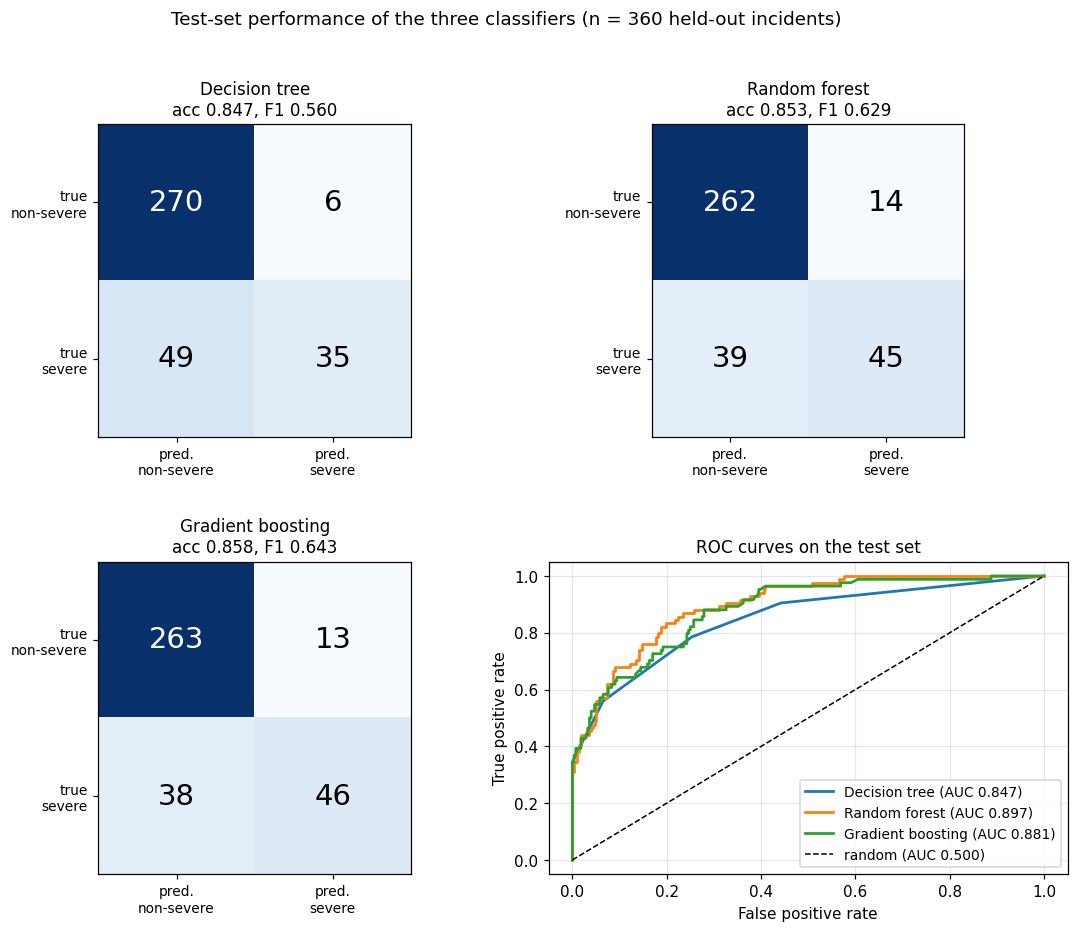

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.6))
axes = axes.ravel()
main = ["Decision tree", "Random forest", "Gradient boosting"]

for ax, name in zip(axes[:3], main):
    cm = confusion[name]
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=19,
                    color="white" if cm[i, j] > cm.max() * 0.55 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred.\nnon-severe", "pred.\nsevere"], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true\nnon-severe", "true\nsevere"], fontsize=9)
    ax.set_title(f"{name}\nacc {metrics[name]['accuracy']:.3f}, "
                 f"F1 {metrics[name]['F1-score']:.3f}", fontsize=11)
    ax.grid(False)

ax = axes[3]
for name in main:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    ax.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC {metrics[name]['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random (AUC 0.500)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the test set", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

fig.suptitle("Test-set performance of the three classifiers (n = 360 held-out incidents)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(hspace=0.40)
save(fig, "p3_4_confusion_and_roc.png")
plt.show()

### 3.4.4 Feature importances

In [40]:
from sklearn.inspection import permutation_importance

importances = pd.DataFrame(
    {name: models[name].feature_importances_ for name in main}, index=FEATURES)
importances["mean rank"] = importances.rank(ascending=False).mean(axis=1)
importances = importances.sort_values("mean rank")
print("Impurity-based feature importances (each column sums to 1):")
print(importances.round(4))
importances.round(4).to_csv(RES_DIR / "p3_4_feature_importances.csv")

# Permutation importance on the test set is model-agnostic and not biased towards
# high-cardinality features, so it is a useful cross-check on the impurity measure.
perm = {}
for name in main:
    r = permutation_importance(models[name], X_test, y_test, n_repeats=30,
                               random_state=RANDOM_STATE, scoring="roc_auc")
    perm[name] = r.importances_mean
perm = pd.DataFrame(perm, index=FEATURES)
print("\nPermutation importance on the test set (drop in ROC-AUC when a feature is shuffled):")
print(perm.round(4))
perm.round(4).to_csv(RES_DIR / "p3_4_permutation_importances.csv")

Impurity-based feature importances (each column sums to 1):
                   Decision tree  Random forest  Gradient boosting  mean rank
current_delay_min         0.3792         0.3741             0.3483     1.0000
rain                      0.2801         0.1942             0.2141     2.3333
major_incident            0.3269         0.1797             0.2101     2.6667
passenger_load            0.0000         0.1474             0.1169     4.5000
peak_hour                 0.0138         0.0806             0.0906     4.6667
critical_hub              0.0000         0.0240             0.0201     5.8333



Permutation importance on the test set (drop in ROC-AUC when a feature is shuffled):
                   Decision tree  Random forest  Gradient boosting
peak_hour                 0.0035         0.0410             0.0445
rain                      0.0605         0.0891             0.0787
major_incident            0.1448         0.1320             0.1181
critical_hub              0.0000         0.0153             0.0223
current_delay_min         0.1462         0.1353             0.1204
passenger_load            0.0000         0.0412             0.0375


saved -> figures\p3_4_feature_importances.png


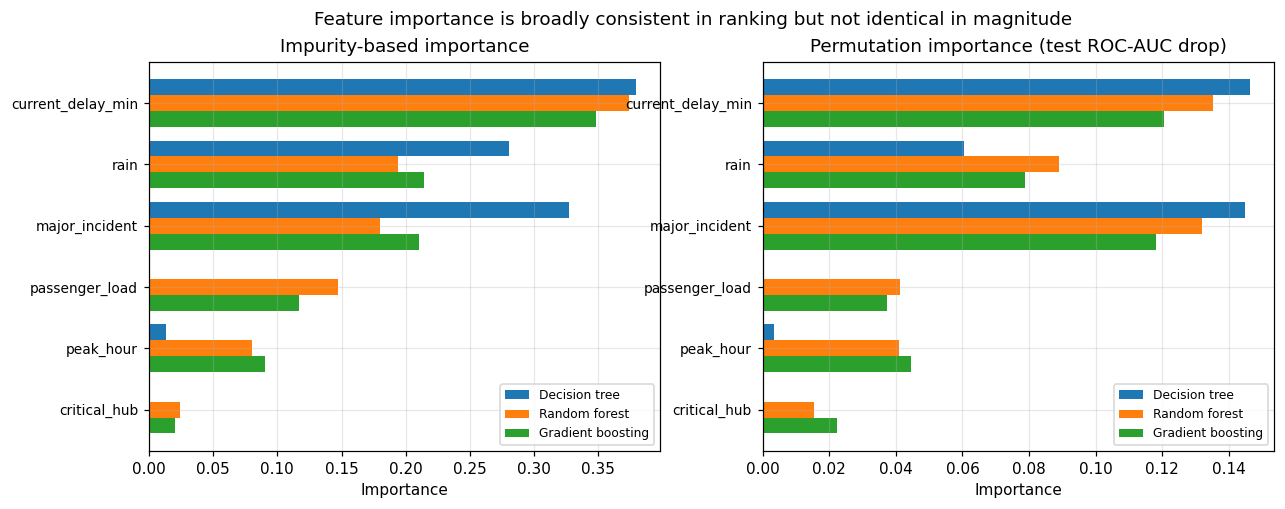

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))
order = importances.index.tolist()
pos = np.arange(len(order))
width = 0.26

for ax, table, title in [
        (axes[0], importances.loc[order, main], "Impurity-based importance"),
        (axes[1], perm.loc[order], "Permutation importance (test ROC-AUC drop)")]:
    for k, name in enumerate(main):
        ax.barh(pos + (k - 1) * width, table[name], height=width, label=name)
    ax.set_yticks(pos); ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle("Feature importance is broadly consistent in ranking but not identical in magnitude")
save(fig, "p3_4_feature_importances.png")
plt.show()

### 3.4.5 Threshold selection and the cost of the two error types

The default threshold of 0.5 is a software convention, not a property of the model, and it
implicitly assumes a false positive and a false negative cost the same. Choosing a better
one is a **model-selection decision**, so it must not be made on the test set. I therefore
select the threshold on out-of-fold predictions from the training data only:

1. generate out-of-fold probabilities for the training set with five-fold stratified
   cross-validation, so every training row receives a prediction from a model that did not
   see it;
2. sweep the threshold on those out-of-fold probabilities and pick the F1-maximising value;
3. refit on the full training set (already done above);
4. apply the chosen threshold to the test set **once**, as a final evaluation.

This keeps the claim that the test set is used only for final evaluation literally true.

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Step 1: out-of-fold probabilities on the TRAINING data only.
best_auc_model = results.loc[main, "ROC-AUC"].idxmax()
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_prob = cross_val_predict(
    RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                           random_state=RANDOM_STATE),
    X_train, y_train, cv=cv_splitter, method="predict_proba")[:, 1]
print(f"selecting the threshold for the {best_auc_model.lower()} "
      f"on {len(oof_prob)} out-of-fold TRAINING predictions")
print(f"out-of-fold ROC-AUC = {roc_auc_score(y_train, oof_prob):.4f}")

# Step 2: sweep the threshold on the out-of-fold predictions.
grid = np.linspace(0.05, 0.85, 81)
rows = []
for t in grid:
    pred_t = (oof_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred_t).ravel()
    rows.append({"threshold": t,
                 "recall": recall_score(y_train, pred_t),
                 "precision": precision_score(y_train, pred_t, zero_division=0),
                 "F1": f1_score(y_train, pred_t),
                 "false positives": fp, "false negatives": fn})
oof_sweep = pd.DataFrame(rows)
chosen_threshold = float(oof_sweep.loc[oof_sweep["F1"].idxmax(), "threshold"])
print(f"\nF1-maximising threshold on training out-of-fold data = {chosen_threshold:.3f} "
      f"(out-of-fold F1 = {oof_sweep['F1'].max():.4f})")
oof_sweep.round(4).to_csv(RES_DIR / "p3_4_threshold_selection_oof.csv", index=False)

selecting the threshold for the random forest on 840 out-of-fold TRAINING predictions
out-of-fold ROC-AUC = 0.9147



F1-maximising threshold on training out-of-fold data = 0.440 (out-of-fold F1 = 0.7301)


In [43]:
# Steps 3-4: apply the selected threshold to the test set exactly once.
prob_best = probabilities[best_auc_model]
final = []
for label, t in [("default 0.5", 0.50), (f"selected {chosen_threshold:.3f}", chosen_threshold)]:
    pred_t = (prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    final.append({"threshold": label,
                  "recall": recall_score(y_test, pred_t),
                  "precision": precision_score(y_test, pred_t, zero_division=0),
                  "F1": f1_score(y_test, pred_t),
                  "false positives": fp, "false negatives": fn})
final = pd.DataFrame(final).set_index("threshold")
print("TEST-SET result of the threshold chosen on training data (evaluated once):")
print(final.round(4))
final.round(4).to_csv(RES_DIR / "p3_4_threshold_final_test.csv")

TEST-SET result of the threshold chosen on training data (evaluated once):
                recall  precision     F1  false positives  false negatives
threshold                                                                 
default 0.5     0.5357     0.7627 0.6294               14               39
selected 0.440  0.5952     0.7143 0.6494               20               34


saved -> figures\p3_4_threshold_tradeoff.png


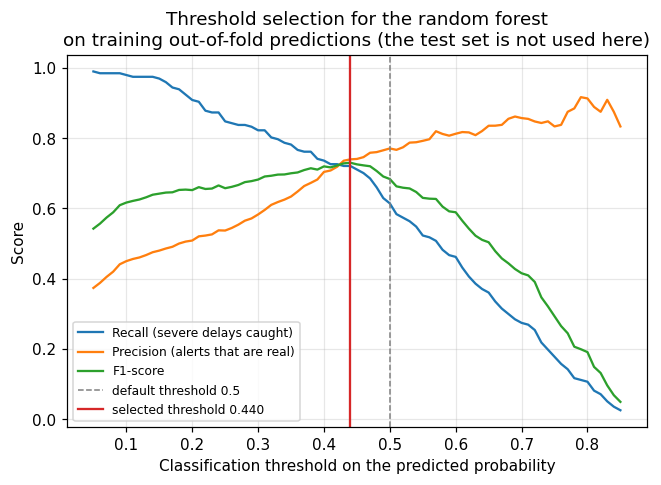

In [44]:
fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.plot(oof_sweep["threshold"], oof_sweep["recall"], label="Recall (severe delays caught)")
ax.plot(oof_sweep["threshold"], oof_sweep["precision"], label="Precision (alerts that are real)")
ax.plot(oof_sweep["threshold"], oof_sweep["F1"], label="F1-score")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="default threshold 0.5")
ax.axvline(chosen_threshold, color="tab:red", ls="-", lw=1.5,
           label=f"selected threshold {chosen_threshold:.3f}")
ax.set_xlabel("Classification threshold on the predicted probability")
ax.set_ylabel("Score")
ax.set_title(f"Threshold selection for the {best_auc_model.lower()}\n"
             "on training out-of-fold predictions (the test set is not used here)")
ax.legend(fontsize=8)
save(fig, "p3_4_threshold_tradeoff.png")
plt.show()

**3.4.2 — Decision tree.** The first split is on `current_delay_min` at a threshold of
7.468 minutes, reducing the root Gini of 0.359. This is a sensible root: the data-generating
process gives a delay above 8 minutes a direct weight of 1.0 and adds a further 0.8 when it
exceeds 5 minutes in the rain, so the current delay carries more marginal signal than any
other single variable. On the test set the depth-3 tree achieves accuracy 0.847,
F1 0.560 and ROC-AUC 0.847, with a confusion matrix of $[[270, 6], [49, 35]]$. Its
precision is the highest of the three models (0.854) but its recall is by far the lowest
(0.417): it raises very few false alarms, but misses 49 of the 84 severe delays in the test
set.

**3.4.3 — All three models.** The random forest reaches accuracy 0.853, F1 0.629 and
ROC-AUC 0.897; gradient boosting reaches accuracy 0.858, F1 0.643 and ROC-AUC 0.881. Both
ensembles clearly beat the single tree, and all three beat the majority-class baseline
(accuracy 0.767, F1 0.000, ROC-AUC 0.500), which is the comparison that shows the models
are doing real work rather than exploiting the class imbalance. The ranking depends on the
metric: gradient boosting is best on accuracy and F1 at the default threshold, while the
random forest is best on ROC-AUC, which is threshold-independent and measures the quality
of the probability ranking. Five-fold cross-validated ROC-AUC on the training data confirms
the ordering is not a quirk of this particular test split.

The gains over the single tree come from different mechanisms. The forest averages 300
decorrelated deep trees, which cuts variance; boosting fits 150 shallow trees sequentially
to the residuals with a learning rate of 0.05, which cuts bias. Both are better placed than
a depth-3 tree to represent the interaction terms in the generating process — a single tree
of depth 3 has only seven internal nodes to express six effects, several of them
interactions.

**3.4.4 — Feature importances.** `current_delay_min` is the most influential variable in
all three models (0.379, 0.374, 0.348), followed by `rain` and `major_incident`. This
matches the generating process, in which the current delay enters two separate terms and
`major_incident` carries the largest single coefficient (1.5).

The importances are **not identical across methods**, and the differences are informative.
The depth-3 tree assigns exactly zero to `critical_hub` and `passenger_load`, because with
only seven splits available it never uses them; the ensembles give `passenger_load` a
substantial 0.147 and 0.117 respectively. `passenger_load` genuinely matters — it appears
in two interaction terms — so the tree's zero is a symptom of its depth limit, not evidence
of irrelevance. Conversely the tree over-weights `major_incident` (0.327) relative to the
ensembles (0.180, 0.210). Two general cautions apply: impurity-based importance is biased
towards continuous and high-cardinality features (the two continuous variables here,
`current_delay_min` and `passenger_load`, take 52% of the total in the forest and 47% in
boosting, against four binary variables sharing the rest), and
importances are shares that must sum to one, so they measure relative rather than absolute
contribution.

The permutation-importance cross-check on the test set agrees on the top variable but
narrows the gap considerably: `current_delay_min` and `major_incident` are almost tied in
every model (0.146 versus 0.145 for the tree, 0.135 versus 0.132 for the forest, 0.120
versus 0.118 for boosting). Since permutation importance is measured in units of lost
ROC-AUC on held-out data and is not biased towards continuous features, this suggests the
impurity measure was overstating the current delay's lead. The safer conclusion is that
the current delay and whether the incident is major are the two dominant predictors, with
rain third, rather than a single clear winner.

**3.4.5 — Recommendation.** I recommend the **random forest**, with the caveat that the
choice is close and depends on how the tool would be used.

The case for it rests on ROC-AUC (0.897 against 0.881 for boosting and 0.847 for the tree).
A control centre would not use hard 0/1 predictions; it would rank live incidents by
predicted severity and act on the top of the list, and ROC-AUC measures exactly that ranking
quality independently of any threshold. The forest also needs less tuning than boosting,
gives free out-of-bag error estimates, and is more robust to the hyperparameters being
somewhat wrong — all of which matter for a model that has to be maintained operationally.
If the tool were instead to issue automatic binary alerts at a fixed threshold, gradient
boosting's higher F1 (0.643) would make it the better choice. The single tree should not be
deployed for prediction despite being the most transparent, though it remains valuable as
an explanation aid, since a depth-3 tree can be printed on one page and shown to
controllers.

**The false-positive / false-negative trade-off is the more consequential decision.** At the
default 0.5 threshold the random forest produces 14 false positives and 39 false negatives
out of 360 test incidents. The two errors are not equally costly. A false positive means
staff are put on standby or passengers are warned about a delay that does not materialise:
the cost is wasted resource and, if repeated, alert fatigue that erodes trust in the system.
A false negative means a severe delay develops with no warning, so no replacement service is
arranged and no passenger information goes out — the cost falls on passengers and on the
operator's punctuality record, and it is generally the larger of the two.

Given that asymmetry, missing 39 of 84 severe delays at the default threshold (recall
0.536) is hard to defend. Selecting the threshold on training out-of-fold predictions gives
0.440, and applying it once to the test set raises recall from 0.536 to 0.595 and cuts
missed severe delays from 39 to 34, at the cost of false alarms rising from 14 to 20.
Test F1 improves slightly, from 0.629 to 0.649.

The size of that gain is worth dwelling on, because it is smaller than a threshold tuned
directly on the test set would suggest. That is the point: a threshold picked by reading
the test set would look better on the test set and would not generalise, because the
apparent optimum partly reflects noise in 360 observations. Selecting on out-of-fold
training predictions gives a more modest but honest estimate of what the rule will do on
new incidents, and it keeps the test set as a genuine held-out sample. If the control
centre wants recall substantially above 0.6, the answer is not a more aggressive threshold
but a better model or more informative features.

Two further points. First, the selection used only training data, so the test figures above
are an unbiased estimate of the chosen rule's field performance. Second, F1 is only a
stand-in for the
operator's real objective: it weights precision and recall equally, which is precisely the
assumption argued against above. In practice the threshold should minimise expected cost,
$C_{\text{FN}}\cdot\text{FN} + C_{\text{FP}}\cdot\text{FP}$, using the operator's own
estimates of the two costs. The same out-of-fold procedure applies unchanged, with that
cost function replacing F1 as the selection criterion. What should not happen is leaving
the threshold at the software default of 0.5, which silently assumes the two errors cost
the same.

**Limitations.** The dataset is synthetic and generated from a known additive score, so
these results say how well the methods recover a structure of that particular kind. Real
incident data would bring measurement error, temporal correlation between incidents,
non-stationarity as the network and timetable change, and covariates not recorded here.
The 360-observation test set also means the metrics carry meaningful sampling uncertainty —
a difference of one or two points in accuracy between the forest and boosting is within
noise, which is why I lean on the cross-validated results as well. Finally, the features are
operational correlates of severe delay, not causes: the model supports prediction and
prioritisation, not conclusions about what would happen if an intervention changed one of
these variables.

---
## Summary of files produced

Figures are written to `figures/` and numerical results to `results/`. Every number quoted
in the report is taken from the outputs above.

In [45]:
print("Figures:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f}")
print("\nResult tables:")
for f in sorted(RES_DIR.glob("*.csv")):
    print(f"  {f}")

Figures:
  figures\p1_2_probability_curves.png
  figures\p1_3_biplot.png
  figures\p1_3_correlation_matrix.png
  figures\p1_3_loadings.png
  figures\p1_3_scree_and_variance.png
  figures\p2_1_data.png
  figures\p2_3_linear_svm.png
  figures\p2_4_feature_map.png
  figures\p2_5_new_predictions.png
  figures\p2_6_kernel_matrices.png
  figures\p3_1_split_comparison.png
  figures\p3_2_bootstrap_probabilities.png
  figures\p3_3_majority_vote.png
  figures\p3_4_class_balance.png
  figures\p3_4_confusion_and_roc.png
  figures\p3_4_decision_tree.png
  figures\p3_4_feature_importances.png
  figures\p3_4_threshold_tradeoff.png

Result tables:
  results\p1_1_coefficient_shift.csv
  results\p1_1_model_fit_comparison.csv
  results\p1_2_predicted_probabilities.csv
  results\p1_3_correlation_matrix.csv
  results\p1_3_descriptives.csv
  results\p1_3_eigenvectors.csv
  results\p1_3_loadings.csv
  results\p1_3_sensitivity_log_traveltime.csv
  results\p1_3_variance_explained.csv
  results\p2_3_svm_C_sweep